# <p style="text-align: center; color: blue; font-size: 55px;"><strong> Projet: Modélisation Credit Risque </strong></p>

###### <p style="text-align: center; color: blue; font-size: 25px;"><strong> Introduction</strong></p>

<p  font-size: 15px;"><strong> Dans un monde où la bancarisation s'intensifie et où les services financiers se digitalisent de plus en plus, les établissements de crédit se retrouvent face à un défi majeur : évaluer, en quelques secondes seulement, le risque associé à chaque demande de prêt. L'augmentation du volume de ces demandes, la diversité des profils des emprunteurs et les exigences réglementaires strictes en matière de gestion des risques rendent impérative l’adoption d’outils de scoring à la fois précis et transparents.

Ce projet vise à concevoir un système de scoring innovant capable de prédire instantanément la probabilité de défaut d’un demandeur en fonction de ses caractéristiques socio-démographiques, de son historique de crédit, ainsi que des données liées au prêt demandé. En exploitant des jeux de données comprenant des informations sur les clients (customers.csv), les prêts (loans.csv) et l’historique des bureaux de crédit (bureau_data.csv), notre objectif est de construire un modèle de risque qui classe chaque demande dans l’une des catégories suivantes : Faible, Moyen, Bon, ou Excellent, en estimant la probabilité de défaut de manière fiable.

Le travail s’organise autour de plusieurs étapes essentielles : une présentation détaillée des jeux de données, le prétraitement et le nettoyage des données, la modélisation à l’aide de techniques avancées telles que la régression logistique et les forêts aléatoires, puis l’évaluation et la comparaison des performances des modèles. L’aboutissement de cette démarche sera la proposition d’un outil d’aide à la décision performant pour l’octroi de crédits.</strong></p>

## <p style="text-align: center; color: blue; font-size: 25px;"><strong> I. Importation des librairies et chargement des données</strong></p>

Dans cette première étape, on importe les principales librairies nécessaires (pandas, numpy, seaborn, matplotlib) et on charge les trois fichiers de données :
- `loans.csv` : informations détaillées sur les prêts (montants, type, dates, défaut, etc.)
- `customers.csv` : caractéristiques des clients (âge, revenus, situation pro, etc.)
- `bureau_data.csv` : historique crédit au bureau (nombre de comptes, delinquencies, utilisation crédit...).




### I.1 **Explications des variables**

### **loans.csv** - Détails des prêts

| Colonne | Signification |
|---------|---------------|
| `loan_id` | ID unique du prêt |
| `cust_id` | ID unique du client |
| `loan_purpose` | Objectif : Home, Auto, Personal, Education |
| `loan_type` | Type : Secured (garanti), Unsecured |
| `sanction_amount` | Montant **approuvé** (INR) |
| `loan_amount` | Montant **emprunté** (INR) |
| `processing_fee` | Frais de traitement |
| `gst` | Taxe GST (18%) |
| `net_disbursement` | **Montant net versé** |
| `loan_tenure_months` | Durée en mois |
| `principal_outstanding` | Capital restant dû |
| `bank_balance_at_application` | Solde bancaire à la demande |
| `disbursal_date` | Date déblocage prêt |
| `installment_start_dt` | Date 1ère échéance |
| `default` | **Cible** : 1=défaut, 0=OK |

### **customers.csv** - Profil clients

| Colonne | Signification |
|---------|---------------|
| `cust_id` | ID unique du client |
| `age` | Âge |
| `gender` | Genre|
| `experience` | Années expérience pro |
| `marital_status` | Etat civil, Marié/Célibataire |
| `employment_status` | Statut professionnel du client|
| `income` | Revenu annuel|
| `number_of_dependants` | Nombre de personnes à charge du client|
| `residence_type` | Type de résidence |
| `years_at_current_address` | nombre d'années passées à l'adresse actuelle. |
| `city` | Ville |
| `state` | État ou région de résidence du client |
| `zipcode` |Code postal de l'adresse du client|

### **bureau_data.csv** - Historique crédit
| Colonne | Signification |
|---------|---------------|
| `cust_id` | ID unique du client |
| `number_of_open_accounts` |Nombre de comptes de crédit ouverts par le client |
| `number_of_closed_accounts` | Nombre de comptes de crédit fermés par le client.|
| `total_loan_months` | Nombre total de mois pendant lesquels le client a eu des prêts |
| `delinquent_months` | Nombre de mois durant lesquels le client a eu des retards de paiement |
| `total_dpd` | Nombre total de jours de retard accumulés sur les paiements |
| `enquiry_count` | Nombre de demandes de crédit effectuées par le client |
| `credit_utilization_ratio` | Ratio de l’utilisation du crédit |



### I.2 **Chargement des données**

In [107]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from credit_risk_scoring.data.preprocess import compute_vif

# Configuration du chemin racine
project_root = os.path.dirname(os.getcwd())
sys.path.append(project_root)

pd.set_option("display.max_columns", 100)

In [108]:
# Import des modules du projet

from credit_risk_scoring.data import (
    load_all_data, convert_currency, merge_data,
    preprocess_dataframe, split_train_test,
    clean_outliers, apply_business_rules,
    feature_engineering, prepare_for_modeling
)
from credit_risk_scoring.models import random_search_logistic
from credit_risk_scoring.features import compute_all_ivs, select_features_by_iv

In [109]:
# Chargement des données
loans = pd.read_csv("../data/loans.csv")
customers = pd.read_csv("../data/customers.csv")
bureau = pd.read_csv("../data/bureau.csv")

print("loans :", loans.shape)
print("customers :", customers.shape)
print("bureau :", bureau.shape)

loans : (50000, 15)
customers : (50000, 12)
bureau : (50000, 8)


In [110]:
customers.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [111]:
customers.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode'],
      dtype='str')

In [112]:
bureau.head()

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [113]:
bureau.columns

Index(['cust_id', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio'],
      dtype='str')

In [114]:
loans.head()

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.000000,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.000000,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.000000,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.000000,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.000000,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [115]:
loans.columns

Index(['loan_id', 'cust_id', 'loan_purpose', 'loan_type', 'sanction_amount',
       'loan_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default'],
      dtype='str')

###### <p style="text-align: center; color: blue; font-size: 25px;"><strong>II. Prétraitement et nettoyage des données</strong></p>

### II.1 **CONVERSION DE LA MONNAIE EN EURO (€ / EUR)**


In [116]:
customers, loans = convert_currency(customers, loans)
 

### II.2 **Fusion des tables `customers`, `loans` et `bureau`**


In [117]:
df = merge_data(customers, loans, bureau)
df = preprocess_dataframe(df)
print(f"df fusionne : {df.shape}")

df fusionne : (50000, 29)


In [118]:
df.head(3)

,age,income,number_of_dependants,years_at_current_address,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,gender_M,marital_status_Single,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
0,44,28446.000000,3,27,33044.000000,27137.000000,542.740000,4884.660000,21709.600000,33,17934.488000,9607.246000,0,1,1,42,0,0,3,7,1,0,1,1,0,0,0,0,0
1,38,13266.000000,3,4,45771.000000,42713.000000,854.260000,7688.340000,34170.400000,30,7802.399000,5105.100000,0,3,1,96,12,60,5,4,1,0,0,1,0,0,1,0,0
2,46,31658.000000,3,24,26411.000000,23870.000000,477.400000,4296.600000,19096.000000,21,17186.389000,16236.462000,0,2,1,82,24,147,6,58,0,0,1,1,0,0,0,1,1


In [119]:
df.info

<bound method DataFrame.info of        age       income  number_of_dependants  years_at_current_address  \
0       44 28446.000000                     3                        27   
1       38 13266.000000                     3                         4   
2       46 31658.000000                     3                        24   
3       55 39017.000000                     1                        15   
4       37 37752.000000                     3                        28   
...    ...          ...                   ...                       ...   
49995   40  8525.000000                     2                        11   
49996   39 34287.000000                     0                         9   
49997   45 14619.000000                     0                        27   
49998   42  5863.000000                     2                        20   
49999   55 34584.000000                     3                        19   

       sanction_amount  loan_amount  processing_fee          gst  \

In [120]:
df.info

<bound method DataFrame.info of        age       income  number_of_dependants  years_at_current_address  \
0       44 28446.000000                     3                        27   
1       38 13266.000000                     3                         4   
2       46 31658.000000                     3                        24   
3       55 39017.000000                     1                        15   
4       37 37752.000000                     3                        28   
...    ...          ...                   ...                       ...   
49995   40  8525.000000                     2                        11   
49996   39 34287.000000                     0                         9   
49997   45 14619.000000                     0                        27   
49998   42  5863.000000                     2                        20   
49999   55 34584.000000                     3                        19   

       sanction_amount  loan_amount  processing_fee          gst  \

### II.3 Conversion de la variable 'default' en numérique

In [121]:
df = preprocess_dataframe(df)
print(f"df apres pretraitement : {df.shape}")

Aucune colonne catégorielle à encoder trouvée.
df apres pretraitement : (50000, 29)


In [122]:
print("Distribution de la variable cible :")
print(df.default.value_counts())
print("\nProportions :")
print(df.default.value_counts(normalize=True))

Distribution de la variable cible :
default
0    45703
1     4297
Name: count, dtype: int64

Proportions :
default
0   0.914060
1   0.085940
Name: proportion, dtype: float64


*On observe qu'il y'a  **45 703** clients n’ont pas eu de défaut de remboursement (*default = 0*), contre **4 297** clients en défaut (*default = 1*). Cela représente environ **91,4 %** de non-défaut et **8,6 %** de défaut.*


### II.4 Séparation des variables explicatives et de la cible + division Train/Test


**On fait un train/test split pour vérifier que le modèle généralise bien et ne se contente pas de « mémoriser » les données d’apprentissage,**
**afin d'éviter le surapprentissage**

In [123]:
df_train, df_test = split_train_test(df)
print(f"df_train : {df_train.shape}")
print(f"df_test : {df_test.shape}")

df_train : (37500, 29)
df_test : (12500, 29)


In [124]:
df_train.head(3)


,age,income,number_of_dependants,years_at_current_address,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,gender_M,marital_status_Single,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,default
12746,59,124597.000000,3,30,364331.000000,257862.000000,5157.240000,46415.160000,206289.600000,28,55000.000000,53025.786000,4,2,152,20,118,4,36,1,0,1,1,0,0,1,0,0,0
32495,44,7865.000000,0,27,12925.000000,12639.000000,252.780000,2275.020000,10111.200000,50,5139.519000,2383.667000,3,1,160,10,62,5,5,0,1,0,1,0,1,0,0,0,0
43675,38,35145.000000,0,26,125499.000000,124256.000000,2485.120000,22366.080000,99404.800000,32,18224.503000,15222.262000,1,1,54,12,67,4,0,1,1,0,0,0,0,1,0,0,0


### II.5 **Vérification des valeurs manquantes et des doublons**

In [125]:
df_train_1, df_test_1 = clean_outliers(df_train, df_test)
print(f"df_train_1 : {df_train_1.shape}")
print(f"df_test_1 : {df_test_1.shape}")

df_train_1 : (37488, 29)
df_test_1 : (12497, 29)


In [126]:
df_train.shape

(37500, 29)

In [127]:
df_train.isna().sum()

age                                0
income                             0
number_of_dependants               0
years_at_current_address           0
sanction_amount                    0
loan_amount                        0
processing_fee                     0
gst                                0
net_disbursement                   0
loan_tenure_months                 0
principal_outstanding              0
bank_balance_at_application        0
number_of_open_accounts            0
number_of_closed_accounts          0
total_loan_months                  0
delinquent_months                  0
total_dpd                          0
enquiry_count                      0
credit_utilization_ratio           0
gender_M                           0
marital_status_Single              0
employment_status_Self-Employed    0
residence_type_Owned               0
residence_type_Rented              0
loan_purpose_Education             0
loan_purpose_Home                  0
loan_purpose_Personal              0
l

In [128]:
df_train.duplicated().sum()

np.int64(0)

In [129]:
df_train.describe()

,age,income,number_of_dependants,years_at_current_address,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,gender_M,marital_status_Single,employment_status_Self-Employed,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,default
count,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000,37500.000000
mean,39.540587,28966.587760,1.944533,15.997787,51696.607307,43956.745067,883.197442,7912.214112,35165.396053,25.961040,14672.014664,10849.287546,2.502907,1.001120,76.111040,4.844853,26.672613,5.008533,43.424880,0.600800,0.450400,0.641200,0.563547,0.198987,0.149920,0.301493,0.349920,0.349920,0.085947
std,9.858344,28861.585685,1.535943,8.921041,68836.162803,59090.485222,1244.409539,10636.287340,47272.388178,12.447444,13350.418886,11474.595159,1.119070,0.814021,43.768520,5.841396,32.779424,2.029236,29.392857,0.489740,0.497540,0.479655,0.495952,0.399243,0.356998,0.458913,0.476951,0.476951,0.280289
min,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,-0.011000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,8822.000000,0.000000,8.000000,12562.000000,10571.000000,211.420000,1902.780000,8456.800000,16.000000,4644.172500,3157.442750,1.000000,0.000000,42.000000,0.000000,0.000000,4.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,20735.000000,2.000000,16.000000,29084.000000,24530.000000,490.600000,4415.400000,19624.000000,24.000000,10971.702500,7315.159500,3.000000,1.000000,71.000000,3.000000,13.000000,5.000000,39.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,46.000000,36588.750000,3.000000,24.000000,56958.000000,50809.000000,1016.620000,9145.620000,40647.200000,35.000000,19633.669000,13574.690250,4.000000,2.000000,107.000000,8.000000,46.000000,6.000000,67.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,70.000000,131989.000000,5.000000,31.000000,573925.000000,526009.000000,58228.978766,94681.620000,420807.200000,59.000000,55000.000000,86313.073000,4.000000,2.000000,223.000000,24.000000,171.000000,9.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [130]:
df_train.columns


Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'gender_M',
       'marital_status_Single', 'employment_status_Self-Employed',
       'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured', 'default'],
      dtype='str')

In [131]:
columns_continuous = [
    'age', 'income', 'number_of_dependants', 'years_at_current_address',
    'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
    'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
    'bank_balance_at_application', 'number_of_open_accounts',
    'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
    'total_dpd', 'enquiry_count', 'credit_utilization_ratio'
]

columns_categorical = [
    'gender_M', 'marital_status_Single', 'employment_status_Self-Employed',
    'residence_type_Owned', 'residence_type_Rented',
    'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
    'loan_type_Unsecured'
]

### ***II.6 Box plot pour visualiser les valeurs aberrantes***

In [132]:
# Vérifier les colonnes disponibles
print("Colonnes disponibles dans df_train :")
print(df_train.columns.tolist())
print(f"\nNombre de colonnes : {len(df_train.columns)}")

Colonnes disponibles dans df_train :
['age', 'income', 'number_of_dependants', 'years_at_current_address', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'gender_M', 'marital_status_Single', 'employment_status_Self-Employed', 'residence_type_Owned', 'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal', 'loan_type_Unsecured', 'default']

Nombre de colonnes : 29


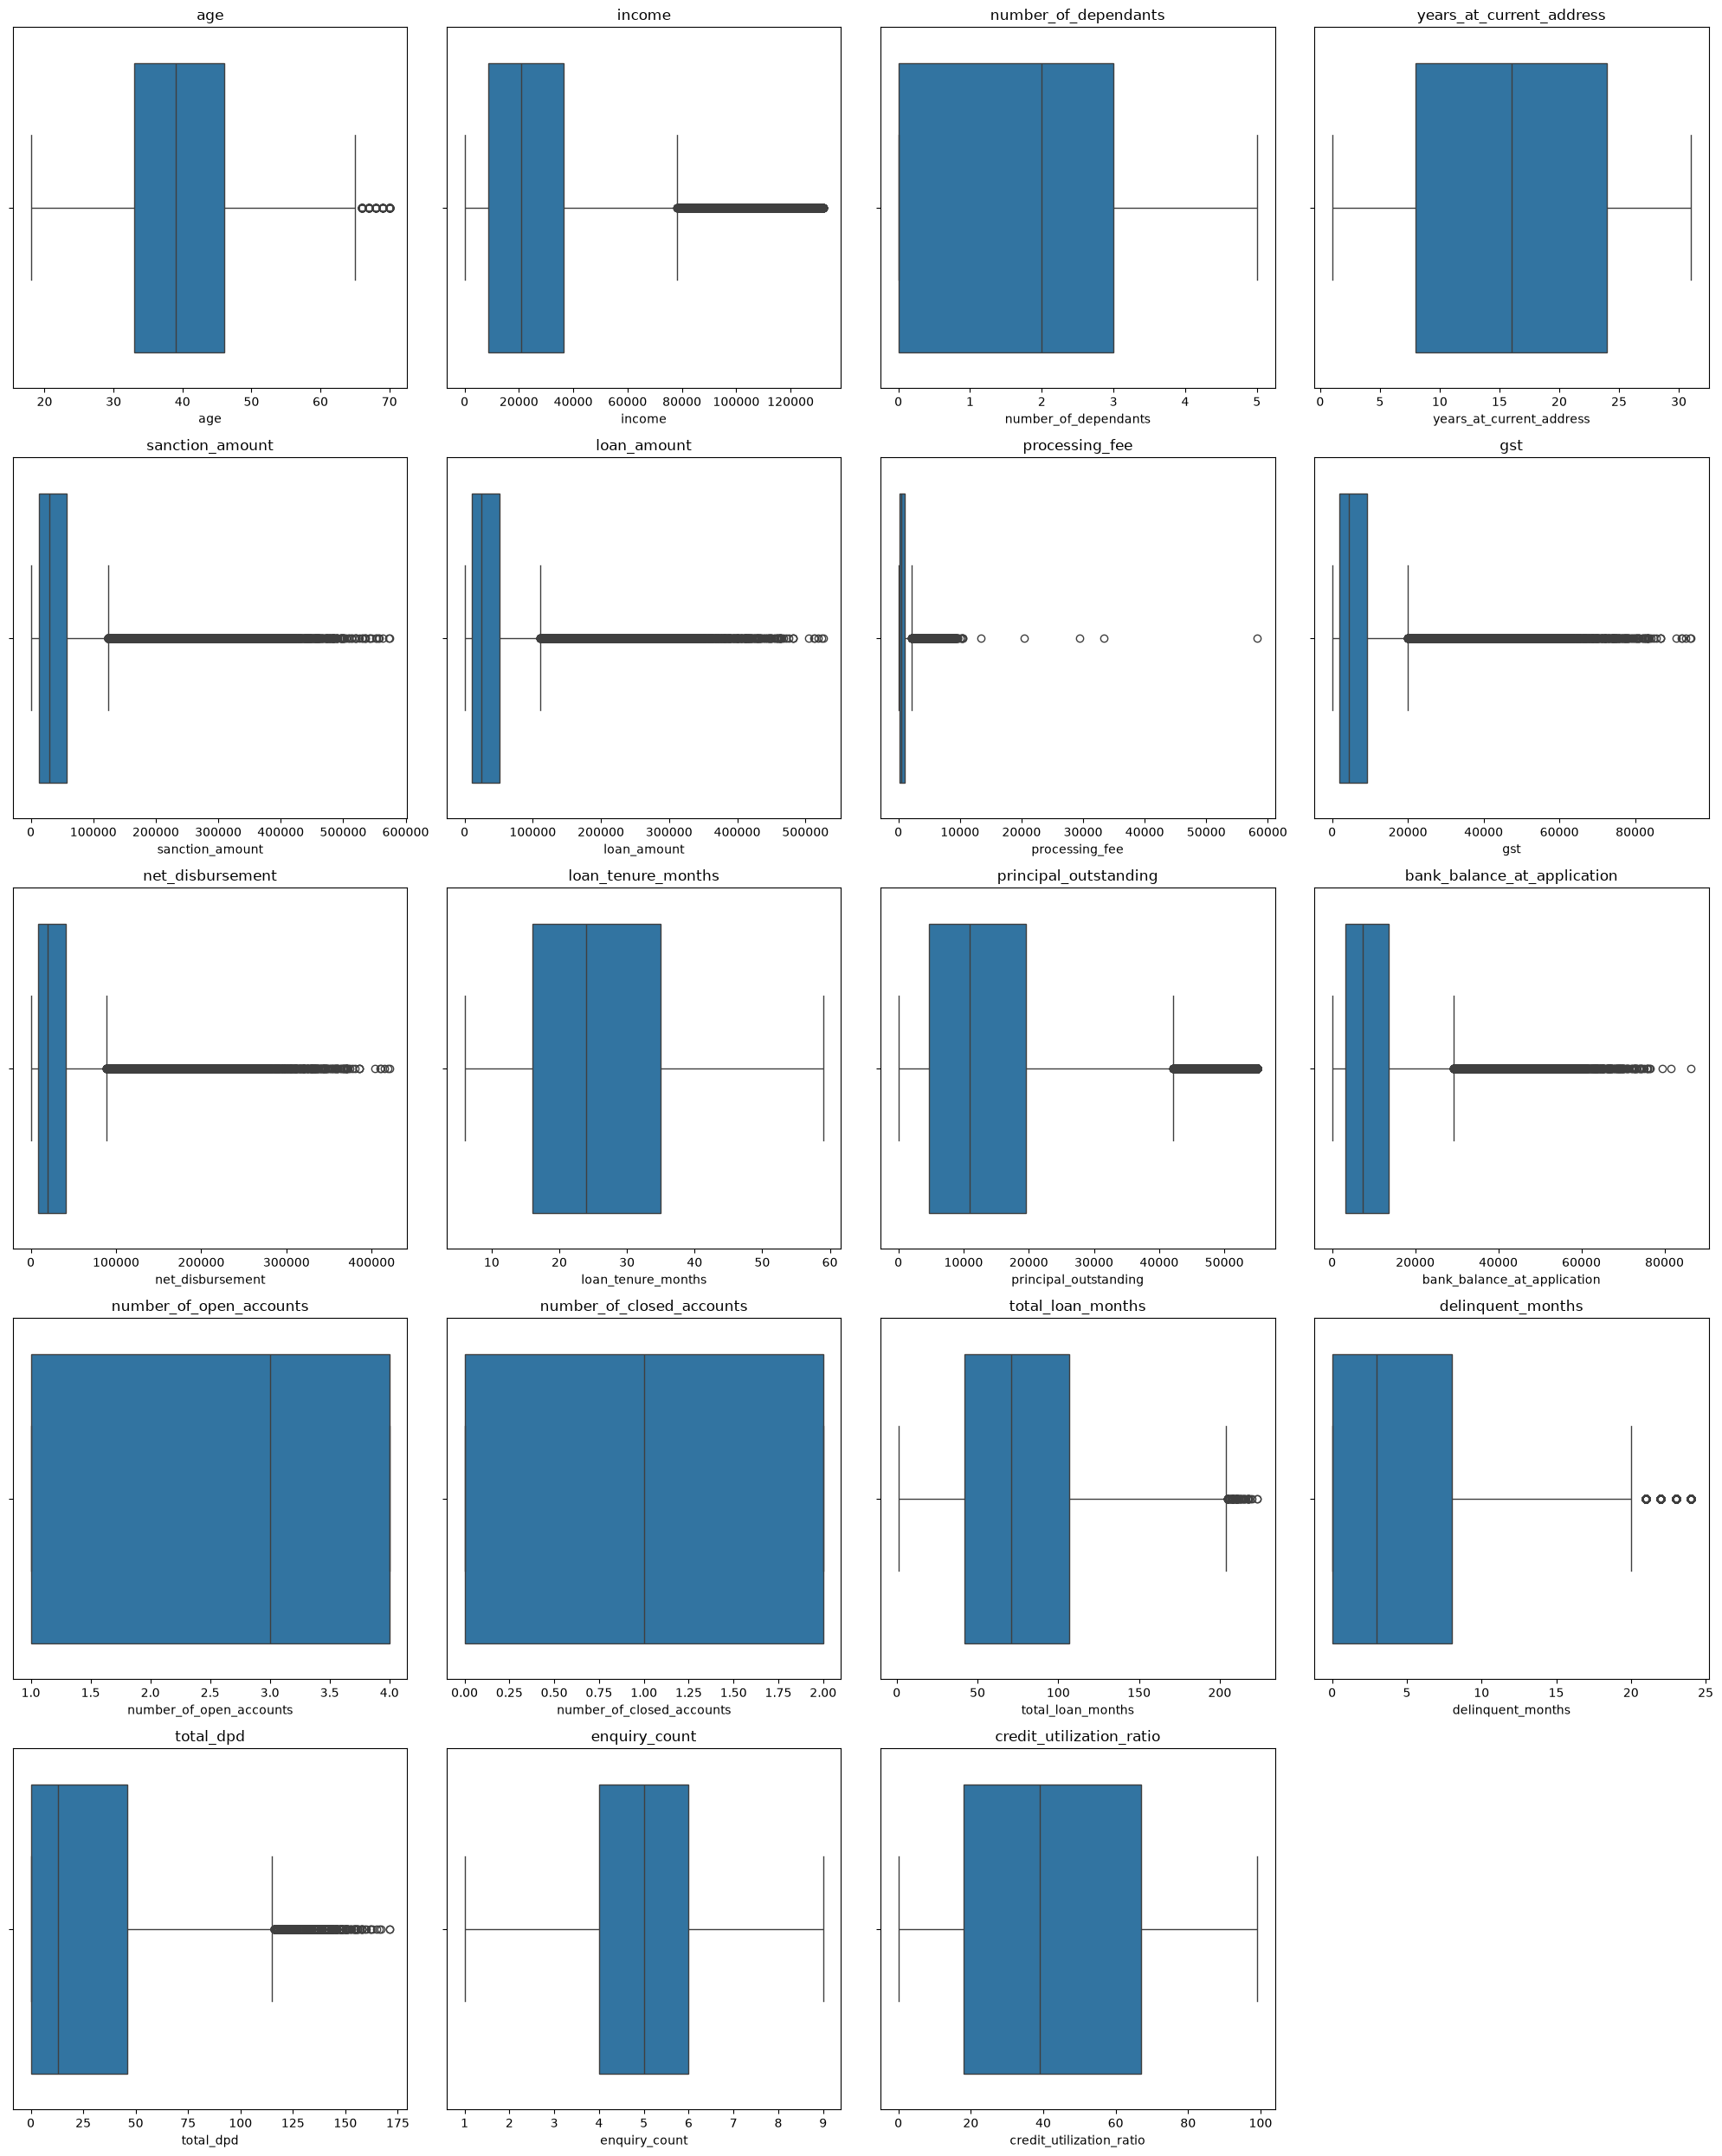

In [133]:
num_plots = len(columns_continuous)
num_cols = 4  
num_rows = (num_plots + num_cols - 1) // num_cols  

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  
axes = axes.flatten()  

for i, col in enumerate(columns_continuous):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col) 
for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### Les boxplots révèlent des valeurs aberrantes sur plusieurs variables continues :
#### <p><strong> Variables monétaires fortement impactées :</strong></p>income, sanction_amount, loan_amount, bank_balance_at_application processing_fee, gst et net_disbursement. 
#### <p><strong> Variables de crédit bureau modérément impactées :</strong></p>principal_outstanding, delinquent_months, total_dpd
#### <p><strong> Variables peu impactées :</strong></p>age, total_loan_months, et les variables discrètes,(number_of_dependants, enquiry_count, etc.) sans outliers détectés.
#### Ces outliers ou valeurs aberrantes sont probablement réels (gros emprunteurs, hauts revenus)
#### et non des erreurs de saisie

### ***II.7 Histogramme***

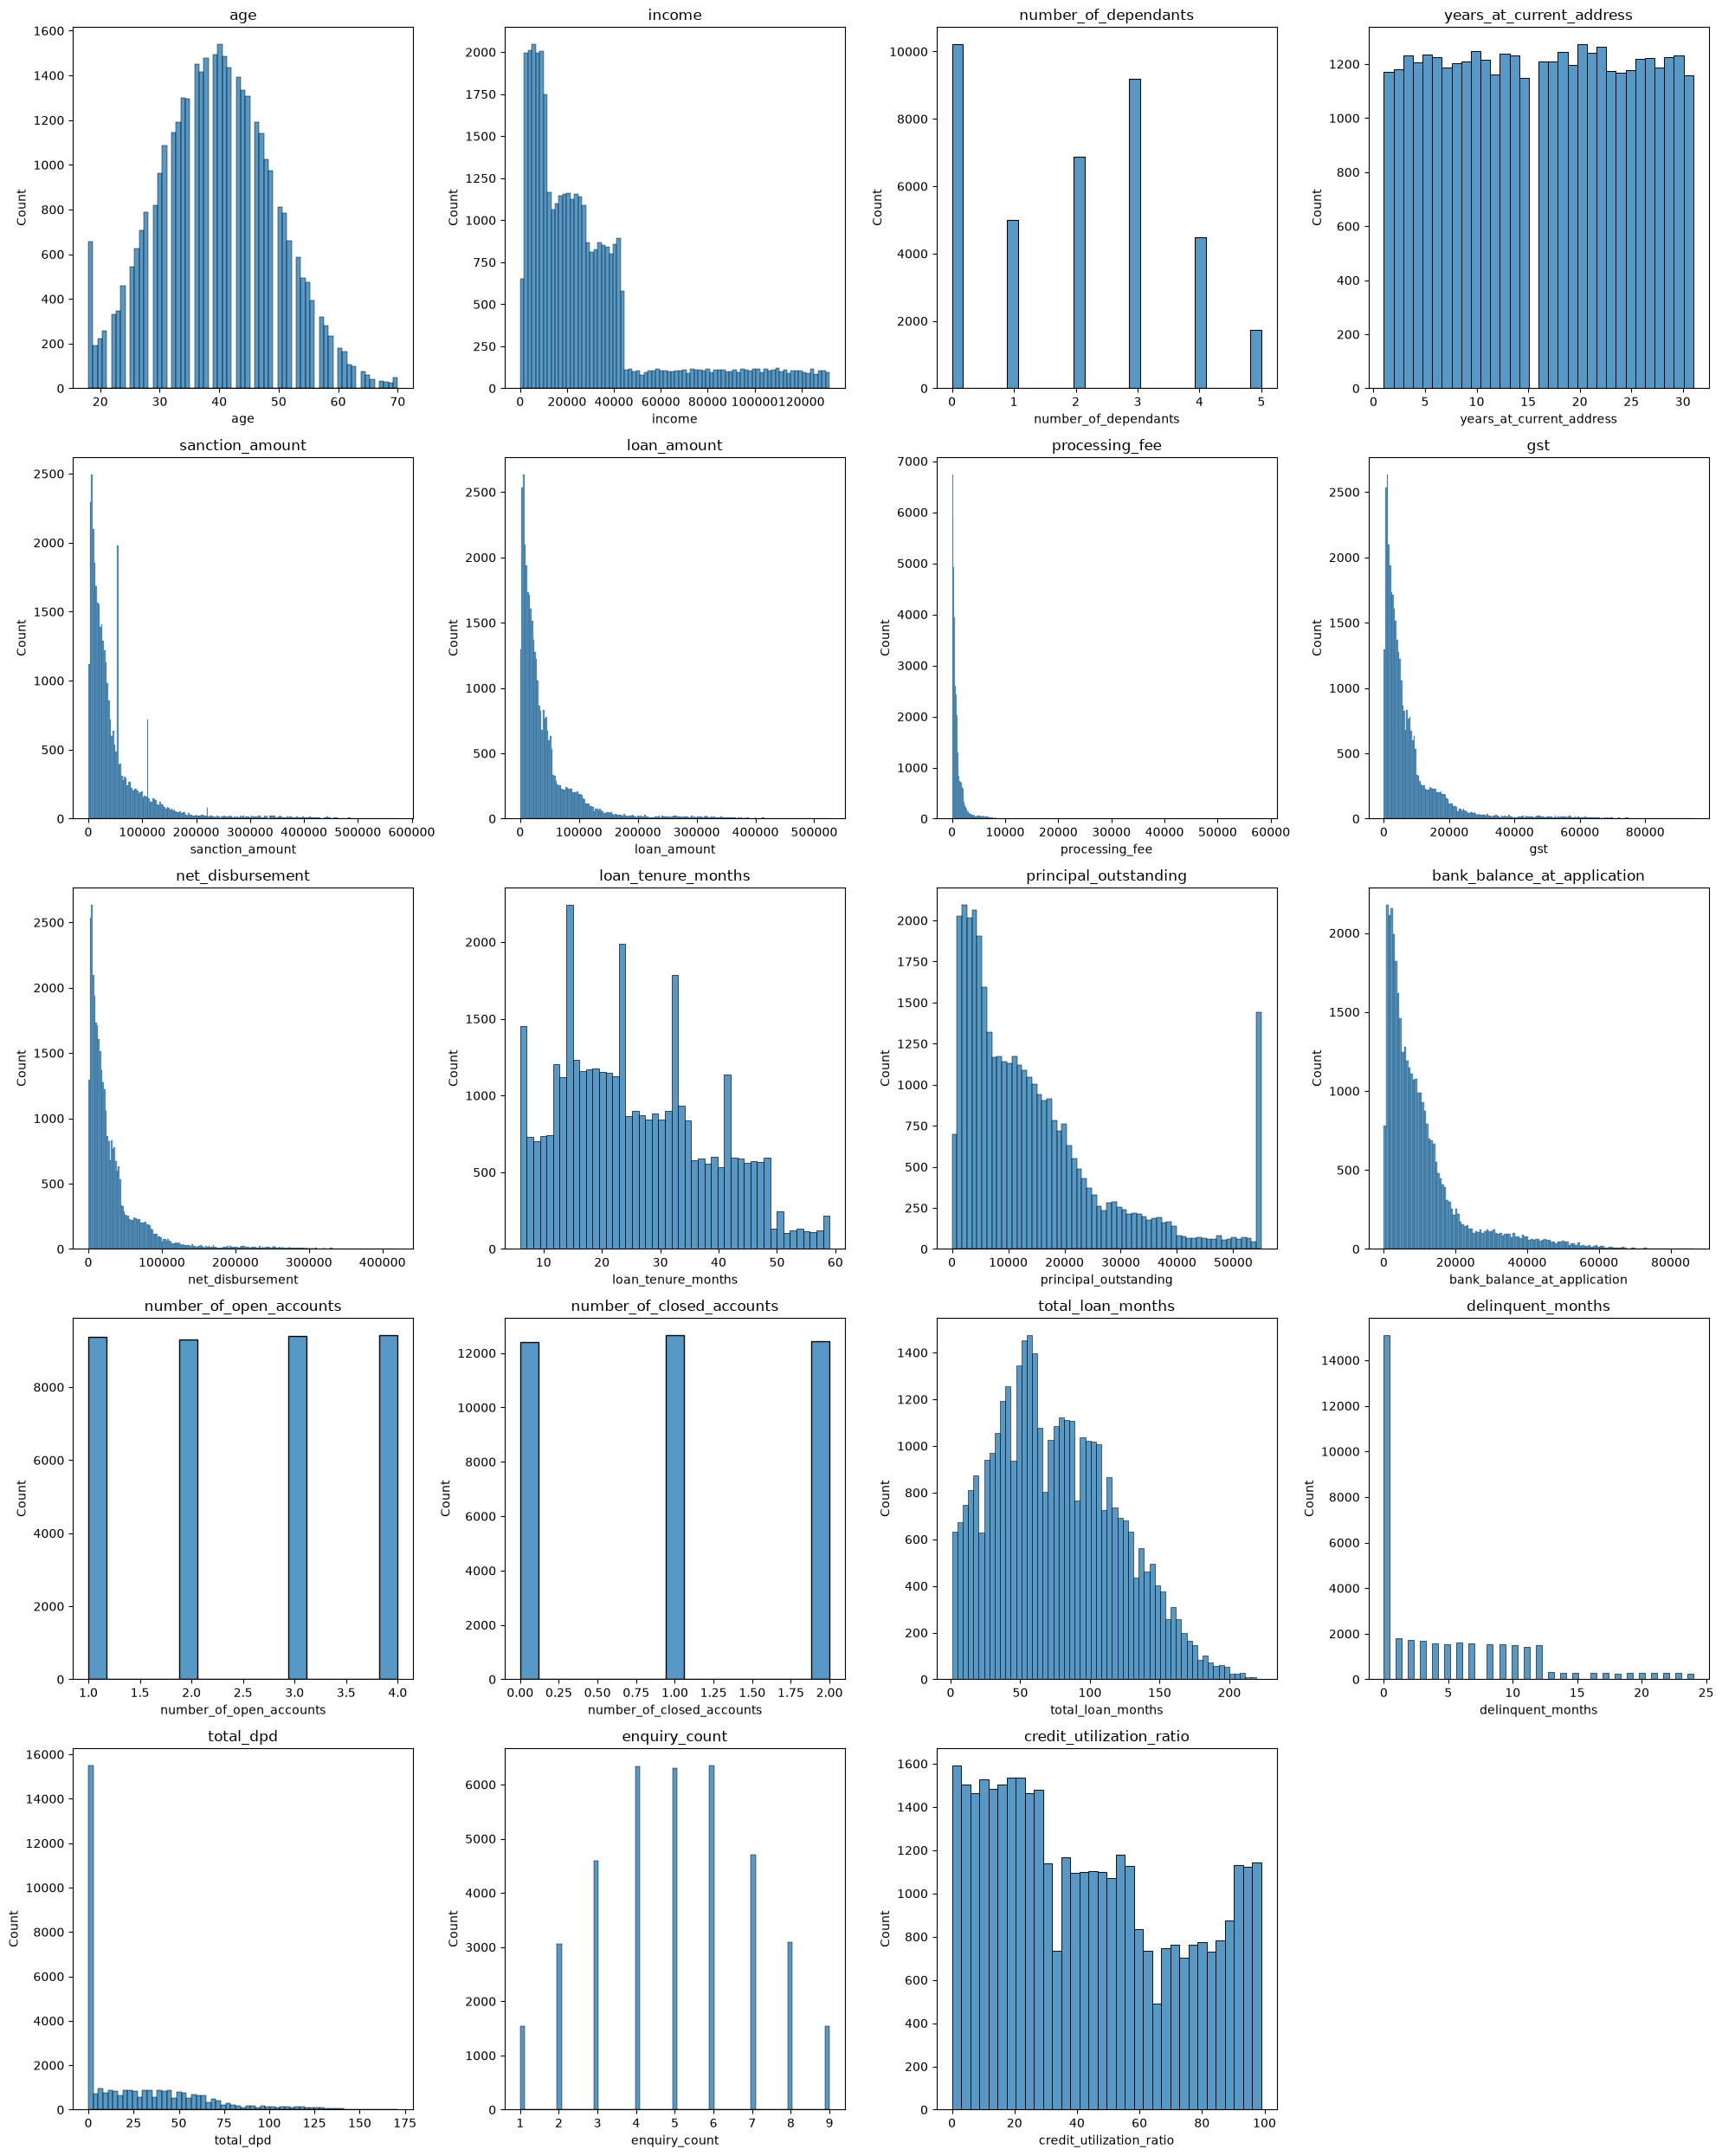

In [134]:
num_plots = len(columns_continuous)
num_cols = 4  
num_rows = (num_plots + num_cols - 1) // num_cols 

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  
axes = axes.flatten()  
for i, col in enumerate(columns_continuous):
    sns.histplot(df_train[col], ax=axes[i])
    axes[i].set_title(col)  


for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### Les histogrammes révèlent deux groupes distincts de distributions :
##### <p><strong>Distributions symétriques / quasi-normales (skewness ≈ 0) :</strong></p>age, number_of_dependants, years_at_current_address, number_of_open_accounts, number_of_closed_accounts, enquiry_count, credit_utilization_ratio
##### <p><strong>Distributions fortement asymétriques à droite :</strong></p>processing_fee (skewness très forte), loan_amount, sanction_amount, net_disbursement, gst (forte), bank_balance_at_application, income (modérée)
##### delinquent_months, total_dpd (légère)
##### <p><strong>Note :</strong></p>processing_fee, gst et net_disbursement partagent la même distribution que loan_amount car elles en sont dérivées.

### Analyse de la variable : Processing Fee

In [135]:
df_train.processing_fee.describe()

count   37500.000000
mean      883.197442
std      1244.409539
min         0.000000
25%       211.420000
50%       490.600000
75%      1016.620000
max     58228.978766
Name: processing_fee, dtype: float64

Les statistiques montrent qu'il n'y a aucune valeur manquante dans processing_fee.
La distribution est très asymétrique à droite : la majorité des frais est concentrée
sur de petites valeurs, avec quelques extrêmes très élevés.
La valeur minimum est 0, certains prêts ne comportant aucun frais de traitement.
Ces valeurs aberrantes sont probablement réels et non des erreurs de saisie.
Une transformation log1p est recommandée pour corriger l'asymétrie
tout en gérant correctement les zéros.

In [136]:
df_train[(df_train.processing_fee / df_train.loan_amount) > 0.03][["loan_amount", "processing_fee"]]

,loan_amount,processing_fee
23981,24574.000000,29367.701254
28174,10626.000000,13359.419404
47089,19118.000000,20448.612447
29305,28776.000000,33400.158058
9898,39886.000000,58228.978766


#### Ces observations correspondent à des prêts dont les frais de traitement
#### dépassent 3% du montant emprunté, ce qui est incohérent d'un point de vue métier.
 

### Nettoyage des valeurs aberrantes via la fonction clean_outliers

In [137]:
df_train_1, df_test_1 = clean_outliers(df_train, df_test)
print(f"df_train_1 : {df_train_1.shape}")
print(f"df_test_1 : {df_test_1.shape}")

df_train_1 : (37488, 29)
df_test_1 : (12497, 29)


### *Application des règles de gestion métier*




#### *Règle 1 : la GST ne doit pas être supérieure à 20%.*

In [138]:
df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2].shape

(0, 29)

#### *Règle 2 : Le décaissement net ne doit pas être supérieur au montant du prêt.*

In [139]:

df_train_1[df_train_1.net_disbursement>df_train_1.loan_amount].shape

(0, 29)

### *Vérification des règles*

In [140]:
print("Règle 1 - GST <= 20% du montant du prêt :")
print(f"  Train : {df_train_1[df_train_1.gst / df_train_1.loan_amount > 0.2].shape[0]} violations")
print(f"  Test : {df_test_1[df_test_1.gst / df_test_1.loan_amount > 0.2].shape[0]} violations")

print("\nRègle 2 - net_disbursement <= loan_amount :")
print(f"  Train : {df_train_1[df_train_1.net_disbursement > df_train_1.loan_amount].shape[0]} violations")
print(f"  Test : {df_test_1[df_test_1.net_disbursement > df_test_1.loan_amount].shape[0]} violations")

Règle 1 - GST <= 20% du montant du prêt :
  Train : 0 violations
  Test : 0 violations

Règle 2 - net_disbursement <= loan_amount :
  Train : 0 violations
  Test : 0 violations


Aucune ligne n'a été trouvée qui enfreint les règles 1 et 2. Les données sont cohérentes.

## Analyse des colonnes catégorielles

In [141]:
columns_categorical

['gender_M',
 'marital_status_Single',
 'employment_status_Self-Employed',
 'residence_type_Owned',
 'residence_type_Rented',
 'loan_purpose_Education',
 'loan_purpose_Home',
 'loan_purpose_Personal',
 'loan_type_Unsecured']

In [142]:
for col in columns_categorical:
    print(col, "-->", df_train_1[col].unique())

gender_M --> [1 0]
marital_status_Single --> [0 1]
employment_status_Self-Employed --> [1 0]
residence_type_Owned --> [1 0]
residence_type_Rented --> [0 1]
loan_purpose_Education --> [0 1]
loan_purpose_Home --> [1 0]
loan_purpose_Personal --> [0 1]
loan_type_Unsecured --> [0 1]


<p style="text-align: center; color: blue; font-size: 28px;"><strong> Analyse exploratoire des données </strong></p>


In [143]:
columns_continuous

['age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'delinquent_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio']

## Colonne Age

In [144]:
df_train_1.groupby("default")['age'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,34265.000000,39.767693,9.880235,18.000000,33.000000,40.000000,46.000000,70.000000
1,3223.000000,37.124729,9.290168,18.000000,31.000000,37.000000,44.000000,70.000000


* Les clients en défaut sont en moyenne plus jeunes que ceux sans défaut, bien que les distributions d’âge se chevauchent fortement. L’âge peut donc être un facteur explicatif, mais à lui seul, il ne suffit pas pour prédire le défaut.

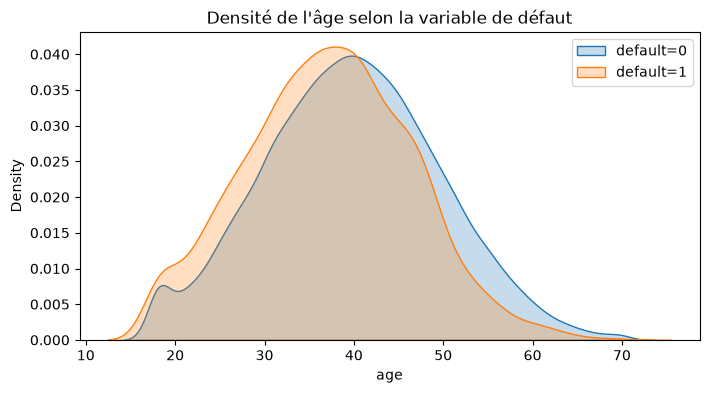

In [145]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['age'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Densité de l'âge selon la variable de défaut")
plt.legend()
plt.show()

**Les défauts sont légèrement plus fréquents chez les clients plus jeunes, mais la différence reste modérée.**

# KDE pour toutes les colones

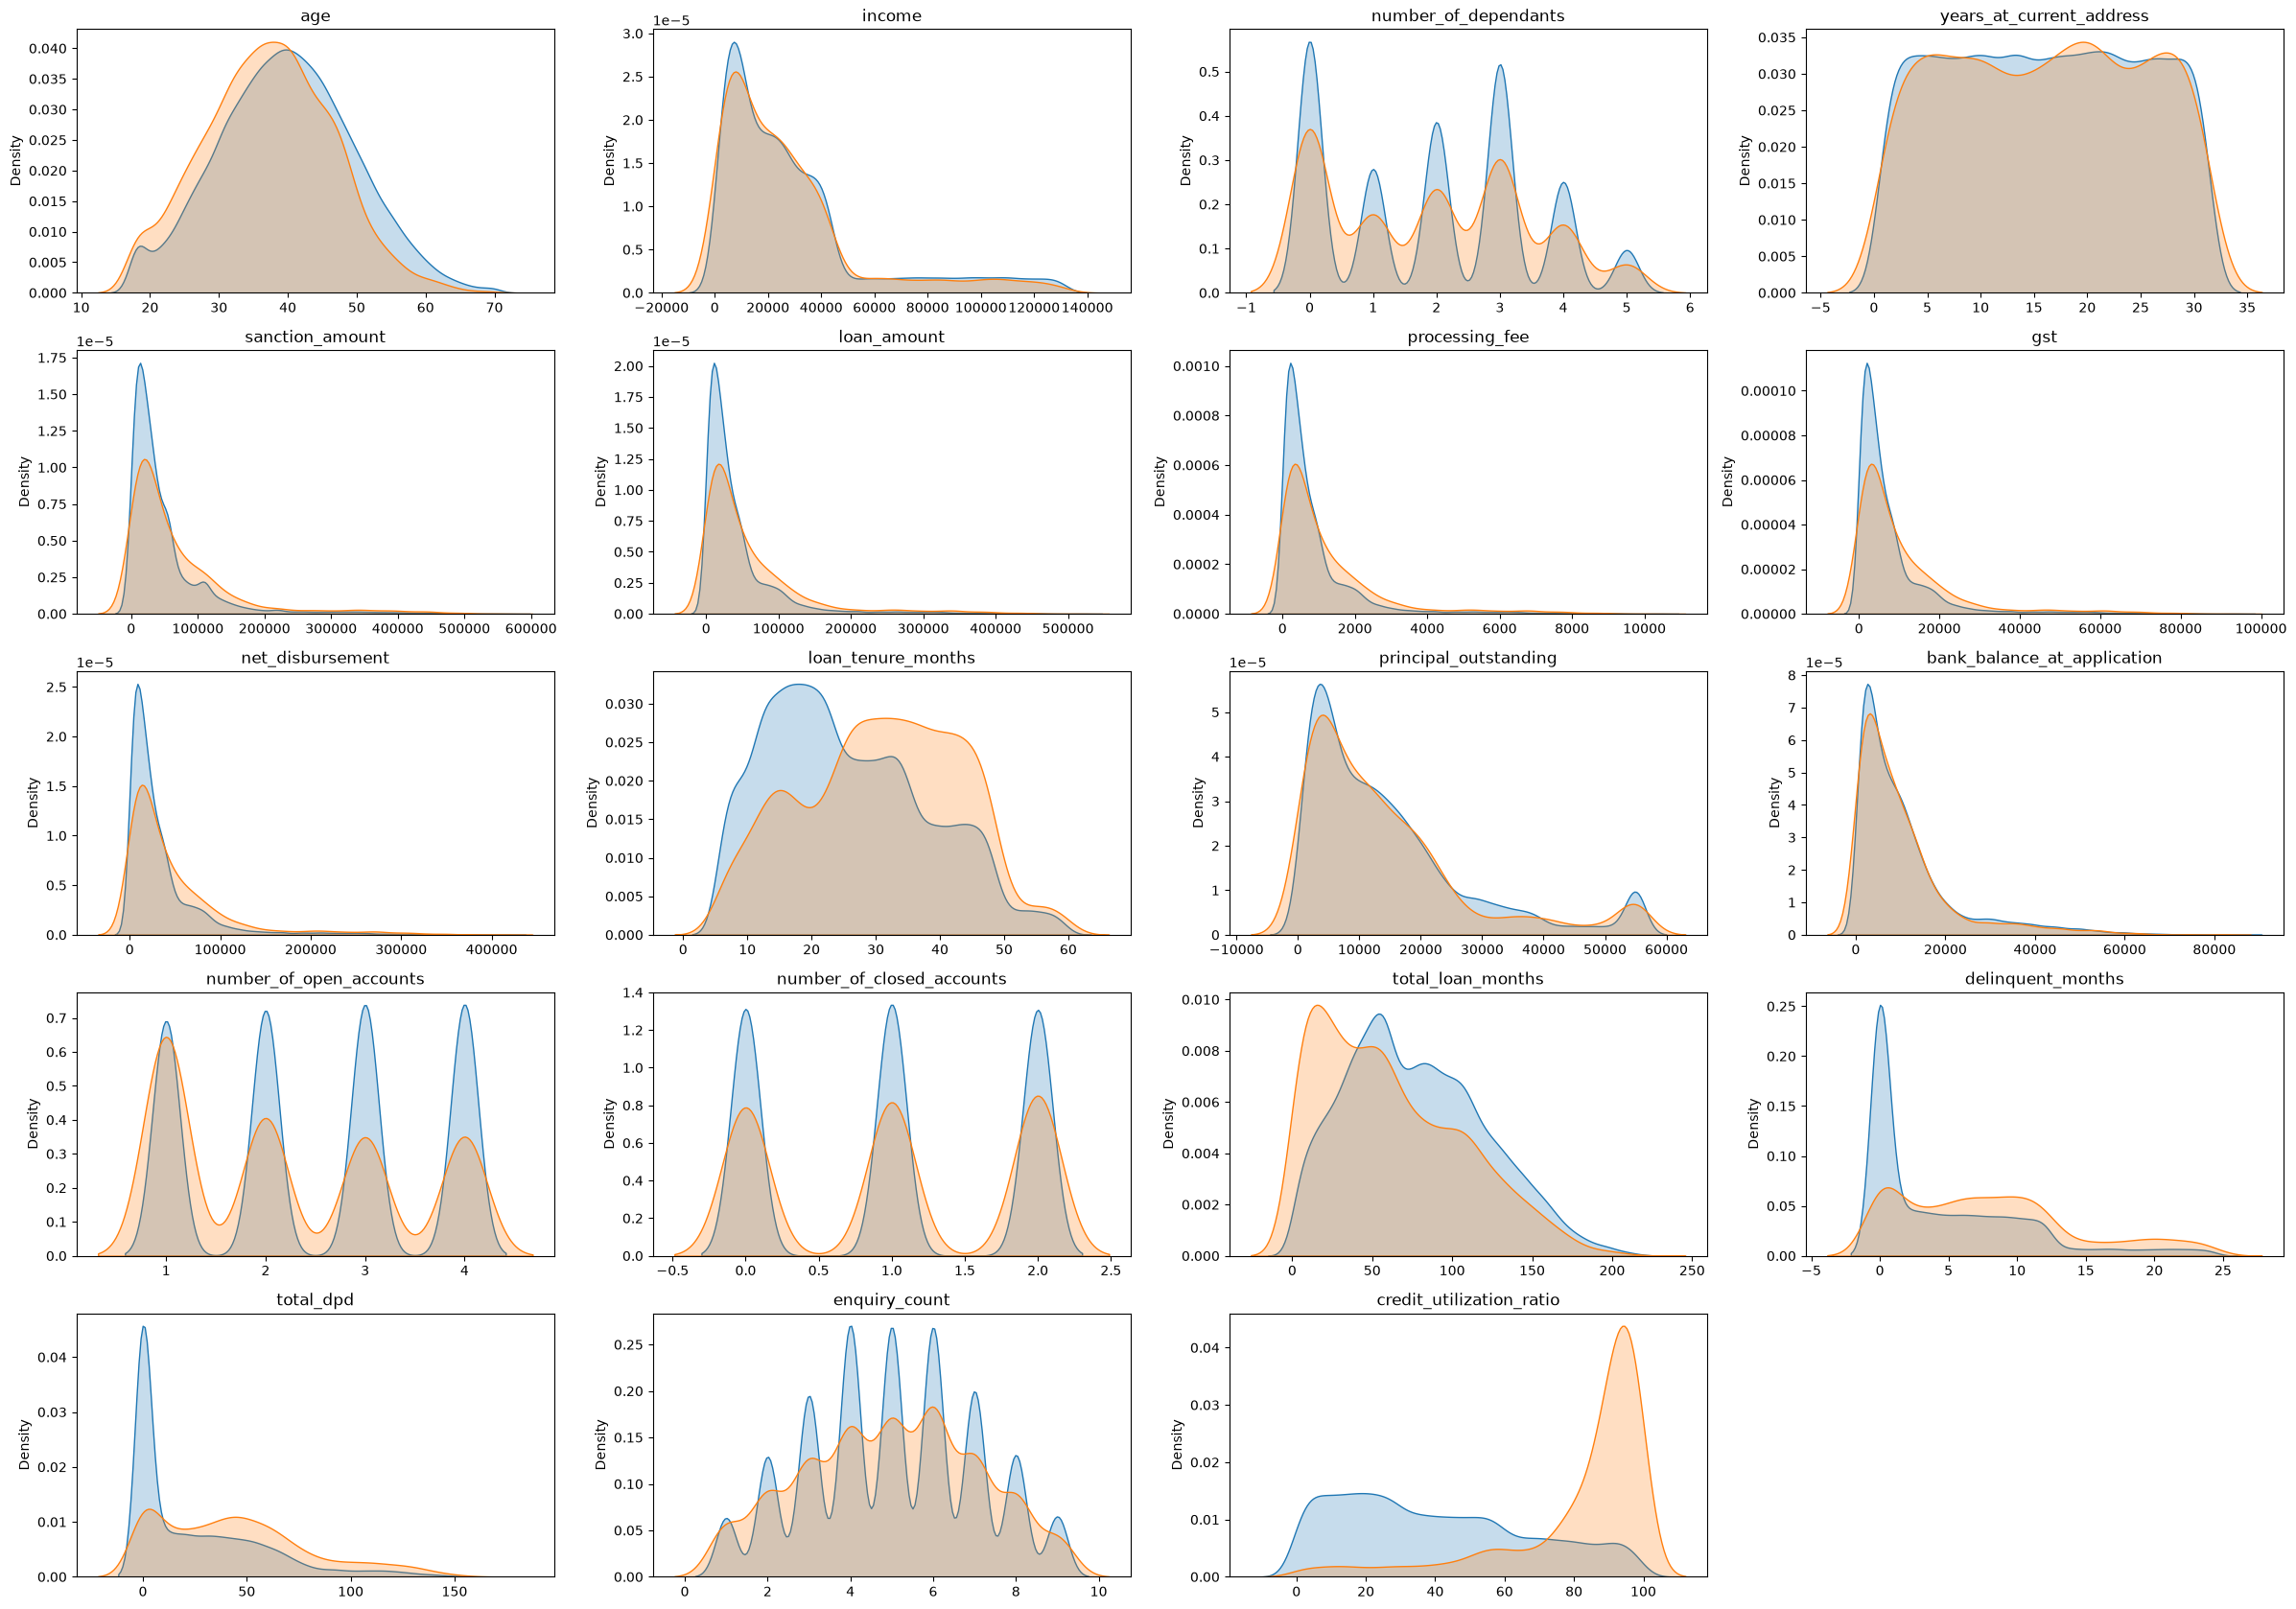

In [146]:
plt.figure(figsize=(24, 20))  # Width, height in inches

for i, col in enumerate(columns_continuous):
    plt.subplot(6, 4, i+1)  # 1 row, 4 columns, ith subplot
    sns.kdeplot(df_train_1[col][df_train_1['default']==0], fill=True, label='default=0')
    sns.kdeplot(df_train_1[col][df_train_1['default']==1], fill=True, label='default=1')
    plt.title(col)        
    plt.xlabel('')
    
plt.tight_layout()
plt.show()


# Les courbes de densité révèlent trois groupes de variables :
#### <p><strong>-Forts prédicteurs du défaut</strong></p> (écart marqué entre les deux groupes) :credit_utilization_ratio , total_dpd , delinquent_months 
####   montrent une séparation claire : plus ces valeurs sont élevées, plus la probabilité de défaut augmente.
#### Ce sont les variables les plus discriminantes, car elles reflètent directement le comportement de remboursement 
#### et le niveau d'endettement du client.  
#### <p><strong>- Variables monétaires</strong></p> (loan_amount, sanction_amount, processing_fee,gst, net_disbursement) :
####    écart apparent (~+41%) mais distributions très chevauchées. Ces variables seules ne traduisent pas réellement 
####   la capacité de remboursement — un prêt élevé n'est pas nécessairement risqué si le revenu est également élevé.
####    Il serait pertinent de créer un ratio Loan-to-Income (LTI) combinant loan_amount et income.
#### <p><strong>-Faible pouvoir discriminant :</strong></p>age , income , bank_balance_at_application,
####   number_of_dependants, years_at_current_address, enquiry_count
####   ne montrent pas de différence marquée entre les deux groupes.

## Ingénierie des caractéristiques (Feature Engineering)


**Générer un ratio prêt/revenu (PSR)**

In [147]:
df_train_1[["loan_amount", "income"]].head(3)


,loan_amount,income
12746,257862.000000,124597.000000
32495,12639.000000,7865.000000
43675,124256.000000,35145.000000


In [148]:
df_train_1['loan_to_income'] = round(
    df_train_1['loan_amount'] / df_train_1['income'].replace(0, pd.NA), 2)
df_train_1['loan_to_income'].describe()

count   37488.000000
mean        1.556711
std         0.973687
min         0.300000
25%         0.770000
50%         1.160000
75%         2.460000
max         4.570000
Name: loan_to_income, dtype: float64

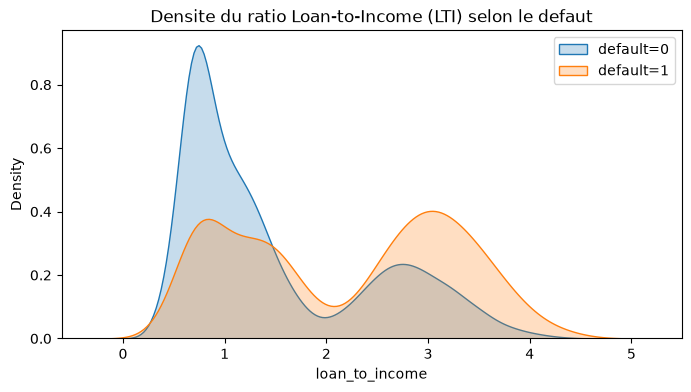

In [149]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_1['loan_to_income'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Densite du ratio Loan-to-Income (LTI) selon le defaut")
plt.legend()
plt.show()


Le graphique confirme que le ratio Loan-to-Income (LTI) est un bon prédicteur du défaut.
Les clients sans défaut (default=0) ont une moyenne LTI de 1.50, contre 2.19
pour les clients en défaut (default=1), soit un écart de +46.5%.
La courbe default=0 est concentrée sur les faibles valeurs de LTI, reflétant un endettement modéré par rapport au revenu.
La courbe default=1 est décalée vers la droite avec une queue plus étalée, indiquant que plus le prêt représente une part importante du revenu,plus le risque de défaut est élevé. Le ratio LTI apporte donc une information discriminante que loan_amount et income ne fournissaient pas individuellement.

**Générer un taux d'impayés**

#### *Le Feature Engineering est déjà appliqué via la fonction feature_engineering()*
#### *df_train_2 et df_test_2 contiennent déjà delinquency_ratio et avg_dpd_per_delinquency*

In [150]:
df_train_2, df_test_2 = feature_engineering(df_train_1, df_test_1)

print("Colonnes disponibles dans df_train_2 :")
print(df_train_2.columns.tolist())
print(f"\nNombre de colonnes : {len(df_train_2.columns)}")

Colonnes disponibles dans df_train_2 :
['age', 'number_of_dependants', 'years_at_current_address', 'sanction_amount', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count', 'credit_utilization_ratio', 'gender_M', 'marital_status_Single', 'employment_status_Self-Employed', 'residence_type_Owned', 'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal', 'loan_type_Unsecured', 'default', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency']

Nombre de colonnes : 27


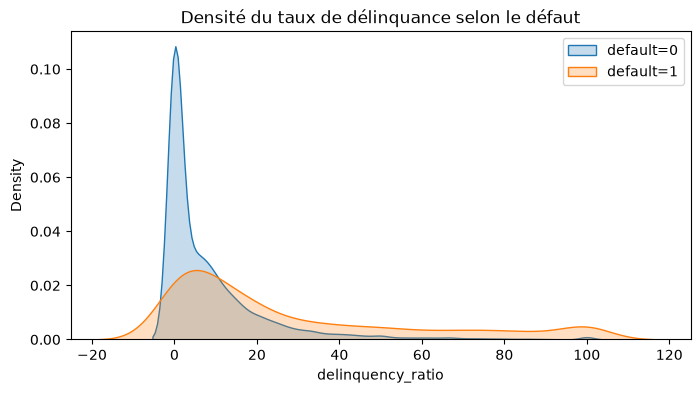

In [151]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_2['delinquency_ratio'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_2['delinquency_ratio'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title(f"Densité du taux de délinquance selon le défaut")
plt.legend()
plt.show()

La courbe default=0 est fortement concentrée autour de 0%, indiquant que
la grande majorité des clients non défaillants ont un taux de retard
très faible (moyenne : 8.66%).

La courbe default=1 est décalée vers la droite et plus étalée, avec une
moyenne de 28.11% — soit +225% par rapport aux non-défaillants.
Plus le taux de retard est élevé, plus le risque de défaut augmente.
C'est la feature engineerée la plus discriminante du dataset, devant loan_to_income, credit_utilization_ratio,
total_dpd et delinquent_months.


### Générer une moyenne de DPD par délinquance

 Cette variable mesure l'intensité moyenne des retards de paiement et s'est révélée fortement discriminante dans l'analyse du risque de défaut.

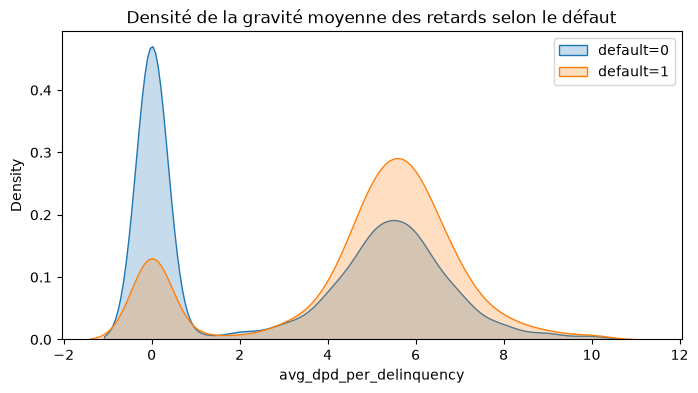

In [152]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df_train_2['avg_dpd_per_delinquency'][df_train_1['default'] == 0], fill=True, label='default=0')
sns.kdeplot(df_train_2['avg_dpd_per_delinquency'][df_train_1['default'] == 1], fill=True, label='default=1')
plt.title("Densité de la gravité moyenne des retards selon le défaut")
plt.legend()
plt.show()

- Le graphique bleu (default = 0) montre une forte concentration des valeurs autour de 0, indiquant que les clients non défaillants présentent peu ou pas de retard moyen.
- Le graphique orange (default = 1) est décalé vers des valeurs plus élevées, ce qui reflète des retards plus longs et plus sévères.
- Le faible chevauchement entre les deux distributions suggère que `avg_dpd_per_delinquency` est une variable fortement discriminante pour la défaillance.


### Analyse de la multicolinéarité (VIF)

Le Variance Inflation Factor (VIF) a été utilisé afin d'évaluer le niveau de colinéarité entre les variables numériques.

In [153]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

Préparation des données via la fonction prepare_for_modeling

In [154]:
X_train, X_test, y_train, y_test, scaler, cols_to_scale = prepare_for_modeling(df_train_2, df_test_2)

In [155]:
X_test.describe()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
count,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000
mean,0.415001,0.375092,0.497293,0.436038,0.568536,0.193486,0.297751,0.348564,0.348564,0.293038,0.106074,0.333844
std,0.188773,0.233792,0.372576,0.295418,0.495300,0.395047,0.457288,0.476535,0.476535,0.226176,0.173081,0.289680
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.188679,0.000000,0.181818,0.000000,0.000000,0.000000,0.000000,0.000000,0.112412,0.000000,0.000000
50%,0.423077,0.339623,0.333333,0.393939,1.000000,0.000000,0.000000,0.000000,0.000000,0.201405,0.042000,0.440000
75%,0.538462,0.547170,0.666667,0.676768,1.000000,0.000000,1.000000,1.000000,1.000000,0.498829,0.134000,0.580000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.004684,1.000000,1.000000


In [156]:
X_train.head(4)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.788462,0.415094,1.000000,0.363636,1,0,1,0,0,0.414520,0.132000,0.590000
32495,0.500000,0.830189,0.666667,0.050505,1,0,0,0,0,0.306792,0.062000,0.620000
43675,0.384615,0.490566,0.000000,0.000000,0,0,1,0,0,0.758782,0.222000,0.560000
9040,0.461538,0.641509,0.666667,0.878788,0,0,0,0,0,0.194379,0.000000,0.000000


In [157]:
vif_result = compute_vif(df_train_2)
print(vif_result)

c:\Users\User\Documents\Projet M2\credit-risk-scoring\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         Column        VIF
0                           age   5.554651
1          number_of_dependants   2.723497
2      years_at_current_address   3.360912
3               sanction_amount 101.084280
4                processing_fee        inf
5                           gst        inf
6              net_disbursement        inf
7            loan_tenure_months   6.170225
8         principal_outstanding  16.316537
9   bank_balance_at_application   9.325626
10      number_of_open_accounts   4.379969
11    number_of_closed_accounts   2.364971
12                enquiry_count   6.333218
13     credit_utilization_ratio   2.895620
14               loan_to_income   6.893445
15            delinquency_ratio   1.930878
16      avg_dpd_per_delinquency   2.903373


Les résultats du VIF indiquent une multicolinéarité sévère, notamment entre les variables financières liées au montant du prêt (certaines avec un VIF infini).  
*Cela nous amène à supprimer les valeurs redondantes.*

A l'exemple du processing_fee, gst, net_disbursement, ces colonnes sont des dérivées directes de loan_amount
Elles n'apportent aucune information supplémentaire au modèle.

In [158]:
from credit_risk_scoring.data.preprocess import compute_vif_with_clean

vif_after, cols_to_scale_clean = compute_vif_with_clean(df_train_2)

print(vif_after)

                         Column      VIF
0                           age 5.265859
1          number_of_dependants 2.719203
2      years_at_current_address 3.336810
3            loan_tenure_months 6.005479
4   bank_balance_at_application 1.798157
5       number_of_open_accounts 4.346294
6     number_of_closed_accounts 2.350572
7                 enquiry_count 6.300588
8      credit_utilization_ratio 2.878920
9                loan_to_income 4.537891
10            delinquency_ratio 1.929426
11      avg_dpd_per_delinquency 2.900313


### Les valeurs du VIF sont globalement inférieures à 10
Ce qui indique l’absence de multicolinéarité sévère dans le modèle.
Certaines variables présentent une corrélation modérée (VIF entre 5 et 6.3), mais la situation reste acceptable pour l’estimation.

In [159]:

corr = df_train_2[cols_to_scale].corr().abs()
corr

,age,number_of_dependants,years_at_current_address,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
age,1.000000,0.253004,0.001310,0.004917,0.028466,0.002756,0.005536,0.000918,0.004269,0.172861,0.000802,0.011486
number_of_dependants,0.253004,1.000000,0.013521,0.007240,0.009366,0.001735,0.003577,0.004270,0.008266,0.033960,0.002756,0.011802
years_at_current_address,0.001310,0.013521,1.000000,0.000336,0.001714,0.001450,0.001418,0.000182,0.007135,0.002036,0.002973,0.004722
loan_tenure_months,0.004917,0.007240,0.000336,1.000000,0.002959,0.008409,0.004835,0.003635,0.005131,0.635631,0.000693,0.001280
bank_balance_at_application,0.028466,0.009366,0.001714,0.002959,1.000000,0.001198,0.002652,0.002680,0.002602,0.037708,0.007779,0.006017
number_of_open_accounts,0.002756,0.001735,0.001450,0.008409,0.001198,1.000000,0.001409,0.542579,0.008914,0.002256,0.324134,0.004632
number_of_closed_accounts,0.005536,0.003577,0.001418,0.004835,0.002652,0.001409,1.000000,0.005775,0.010799,0.005018,0.004425,0.000131
enquiry_count,0.000918,0.004270,0.000182,0.003635,0.002680,0.542579,0.005775,1.000000,0.007859,0.000642,0.178095,0.002778
credit_utilization_ratio,0.004269,0.008266,0.007135,0.005131,0.002602,0.008914,0.010799,0.007859,1.000000,0.008954,0.000621,0.003286
loan_to_income,0.172861,0.033960,0.002036,0.635631,0.037708,0.002256,0.005018,0.000642,0.008954,1.000000,0.004726,0.003687


In [160]:
high_corr = corr[corr > 0.95]
high_corr


,age,number_of_dependants,years_at_current_address,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
age,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_dependants,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_at_current_address,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_tenure_months,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_balance_at_application,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_open_accounts,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
number_of_closed_accounts,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
enquiry_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
credit_utilization_ratio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
loan_to_income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


## Résultat excellent 
Aucune paire de variables n'a une corrélation > 0.95 (hors diagonale), seule la diagonale affiche 1.0 (chaque variable avec elle-même).

Tout le reste est NaN ce qui signifie corrélation ≤ 0.95.

In [161]:
# Sauvegarde des résultats VIF
vif_df = calculate_vif(df_train_2[cols_to_scale])
selected_numeric_features_vif = vif_df['Column'].values
print(selected_numeric_features_vif)

# Heatmap de corrélation
cols_for_heatmap = list(cols_to_scale) + ['default']

<ArrowStringArray>
[                        'age',        'number_of_dependants',
    'years_at_current_address',          'loan_tenure_months',
 'bank_balance_at_application',     'number_of_open_accounts',
   'number_of_closed_accounts',               'enquiry_count',
    'credit_utilization_ratio',              'loan_to_income',
           'delinquency_ratio',     'avg_dpd_per_delinquency']
Length: 12, dtype: str


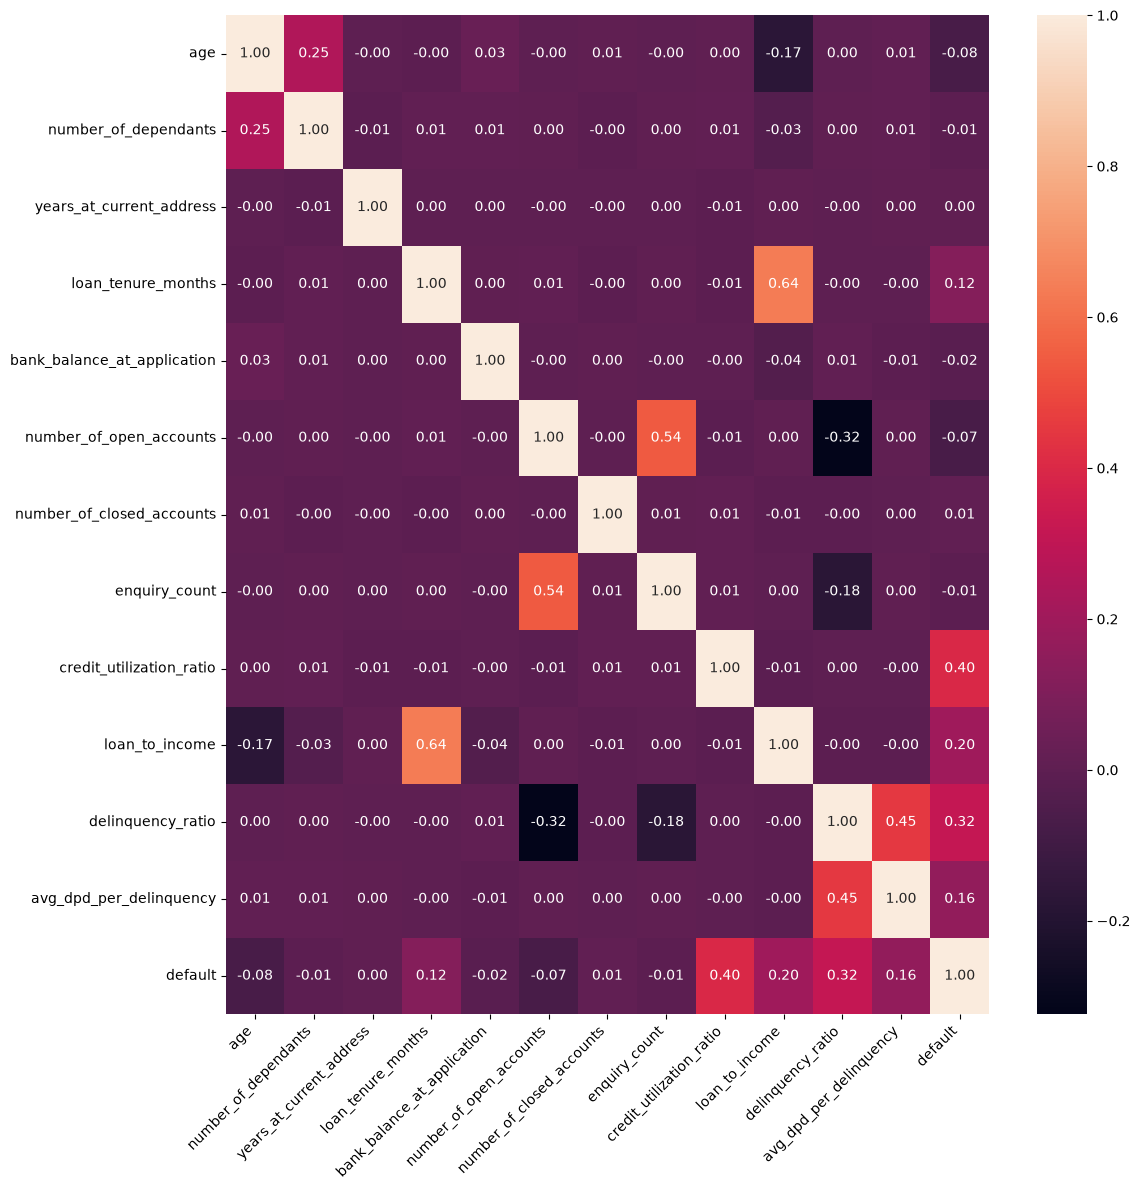

In [162]:
plt.figure(figsize=(12, 12))
cm = df_train_2[cols_for_heatmap].corr()
sns.heatmap(cm, annot=True, fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Sélection de caractéristiques : Caractéristiques catégorielles

In [163]:
X_train_f = df_train_2.copy()
X_test_f  = df_test_2.copy()

# Calcul du WOE et IV

### Sélection des variables par Information Value (IV)

Le Weight of Evidence (WOE) mesure le pouvoir de séparation d'une modalité d'une variable par rapport à la variable cible.

 L'Information Value (IV) mesure la capacité prédictive globale d'une variable.

### **Règle d'interprétation classique de l'IV :**
  - IV < 0.02 : variable non prédictive
 - 0.02 ≤ IV < 0.1 : faible pouvoir prédictif
  - 0.1 ≤ IV < 0.3 : pouvoir prédictif moyen
  - IV ≥ 0.3 : fort pouvoir prédictif
 
 Les variables présentant un IV supérieur à 0.02 ont été retenues pour la phase de modélisation.


In [164]:
from credit_risk_scoring.features import compute_all_ivs, select_features_by_iv


### Calcul de l'IV pour toutes les variables

In [165]:
iv_values = compute_all_ivs(X_train, y_train)
 


In [166]:
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

iv_df = pd.DataFrame(
    list(iv_values.items()),
    columns=['Feature', 'IV']
).sort_values('IV', ascending=False).reset_index(drop=True)

iv_df

,Feature,IV
0,credit_utilization_ratio,2.347201
1,delinquency_ratio,0.692358
2,loan_to_income,0.479844
3,avg_dpd_per_delinquency,0.326182
4,loan_purpose_Home,0.284662
5,loan_tenure_months,0.233845
6,residence_type_Rented,0.196018
7,residence_type_Owned,0.191480
8,loan_purpose_Personal,0.163193
9,loan_type_Unsecured,0.163193


  La variable `loan_purpose_Personal` présente un IV de 0.1632, ce qui correspond à un pouvoir prédictif MOYEN (0.1 < IV < 0.3).
 
  Les variables avec un fort pouvoir prédictif (IV > 0.3) sont :
  - `credit_utilization_ratio` : 2.35 (très fort)
  - `delinquency_ratio` : 0.69
  - `loan_to_income` : 0.48
  - `avg_dpd_per_delinquency` : 0.33
  
  Les variables avec un pouvoir prédictif moyen (0.1 < IV < 0.3) sont :
 - `loan_purpose_Home` : 0.28
  - `loan_tenure_months` : 0.23
  - `residence_type_Rented` : 0.20
  - `residence_type_Owned` : 0.19
  - `loan_type_Unsecured` : 0.16
  - `loan_purpose_Personal` : 0.16
  
  Les variables avec un faible pouvoir prédictif (0.02 < IV < 0.1) sont :
  - `age` : 0.08
  - `number_of_open_accounts` : 0.05
  
 Les variables non prédictives (IV < 0.02) seront exclues du modèle.


### Sélection des variables avec IV > 0.02

In [167]:
selected_features_iv = select_features_by_iv(iv_values, threshold=0.02)

print(f"{len(selected_features_iv)} variables retenues sur {len(iv_values)} :")
print(selected_features_iv)

12 variables retenues sur 12 :
['age', 'loan_tenure_months', 'number_of_open_accounts', 'credit_utilization_ratio', 'residence_type_Owned', 'residence_type_Rented', 'loan_purpose_Home', 'loan_purpose_Personal', 'loan_type_Unsecured', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency']


## Encodage des caractéristiques

In [168]:
X_train_reduced = X_train[selected_features_iv].copy()
X_test_reduced = X_test[selected_features_iv].copy()

In [169]:
# Renommage pour cohérence avec la suite du pipeline
X_train_final = X_train_reduced.copy()
X_test_final  = X_test_reduced.copy()

In [170]:
X_train_final.head(5)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
12746,0.788462,0.415094,1.000000,0.363636,1,0,1,0,0,0.414520,0.132000,0.590000
32495,0.500000,0.830189,0.666667,0.050505,1,0,0,0,0,0.306792,0.062000,0.620000
43675,0.384615,0.490566,0.000000,0.000000,0,0,1,0,0,0.758782,0.222000,0.560000
9040,0.461538,0.641509,0.666667,0.878788,0,0,0,0,0,0.194379,0.000000,0.000000
13077,0.769231,0.169811,0.000000,0.717172,1,0,0,1,1,0.046838,0.000000,0.000000


In [171]:
X_test_final.head(5)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
19205,0.346154,0.754717,0.333333,0.989899,1,0,1,0,0,0.550351,0.000000,0.000000
15514,0.480769,0.226415,1.000000,0.323232,1,0,0,0,0,0.220141,0.000000,0.000000
30367,0.230769,0.547170,0.666667,0.828283,1,0,0,0,0,0.180328,0.000000,0.000000
35347,0.365385,0.754717,1.000000,0.484848,1,0,1,0,0,0.571429,0.024000,0.700000
41814,0.576923,0.716981,0.666667,0.979798,0,0,1,0,0,0.407494,0.107000,0.640000


<p style="text-align: center; color: blue; font-size: 28px;"><strong> Entrainement du modèle </strong></p>

### **Stratégie d'entraînement des modèles :**

L'entraînement des modèles a été structuré en trois tentatives successives afin d'évaluer :
  1. L'impact du déséquilibre des classes
  2. L'effet de l'optimisation des hyperparamètres
  3. L'apport des techniques avancées de rééchantillonnage
  
  **Modèles étudiés :** Régression logistique, Random Forest, XGBoost
  
  **Métrique d'évaluation :** La métrique principale retenue pour la comparaison est le F1-score, particulièrement adaptée aux problèmes de classification déséquilibrée.

### *Tentative1: Modélisation sans traitement du déséquilibre*

#### *Régression logistique, RandomForest et XGB*
#### *Pas de traitement du déséquilibre des classes*

In [172]:
y_train = y_train.loc[X_train_final.index]
y_test  = y_test.loc[X_test_final.index]

print("Après correction :")
print("X_train_final :", X_train_final.shape)
print("y_train         :", y_train.shape)
print("X_test_final  :", X_test_final.shape)
print("y_test          :", y_test.shape)

Après correction :
X_train_final : (37488, 12)
y_train         : (37488,)
X_test_final  : (12497, 12)
y_test          : (12497,)


In [173]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



###  Résultats — Régression Logistique (sans traitement déséquilibre)
### ──────────────────────────────────────────────────────────────────
####  Classe 0 (non-défaut) — très bien détectée :
####    → Précision 0.97 | Rappel 0.99 | F1 0.98
####    → Le modèle identifie quasi parfaitement les bons payeurs
####   Classe 1 (défaut) — moins bien détectée :
####    → Précision 0.85 | Rappel 0.72 | F1 0.78
####    → Le modèle rate 28% des défauts (faux négatifs)
####    → Problématique en credit scoring : un défaut non détecté = perte financière
####  Déséquilibre des classes visible :
####    → 11 423 non-défauts (classe 0) vs 1 074 défauts (classe 1)
####    → Ratio ≈ 91% / 9% → classes très déséquilibrées
####  Accuracy globale de 96% trompeuse :
####    → Portée par la classe majoritaire (classe 0)
####    → F1-score de la classe 1 (0.78) est la métrique à surveiller

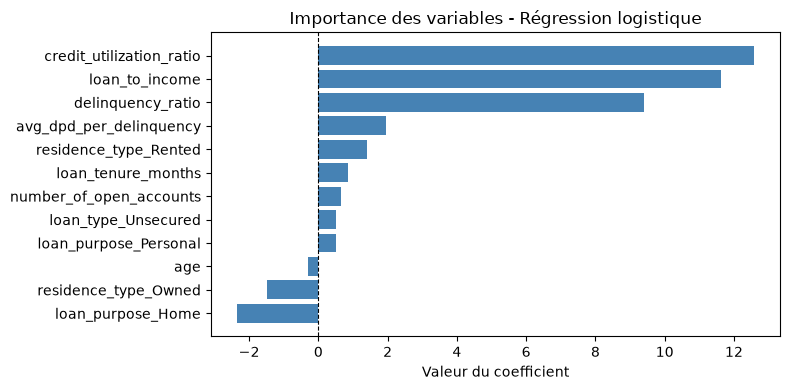

In [174]:
# Importance des variables — Régression Logistique 
# Les coefficients indiquent le sens et la force de l'impact
# de chaque variable sur la probabilité de défaut :
# → Coefficient positif : augmente le risque de défaut
# → Coefficient négatif : diminue le risque de défaut

feature_importance = model.coef_[0]

coef_df = pd.DataFrame(
    feature_importance,
    index=X_train_final.columns,
    columns=['Coefficients']
).sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Valeur du coefficient')
plt.title('Importance des variables - Régression logistique')
plt.tight_layout()
plt.show()


### 🔴 Variables augmentant le risque de défaut (coefficients positifs) :
   → credit_utilization_ratio : variable la plus impactante
   
   → loan_to_income           : ratio endettement/revenu élevé = risque élevé
   
   → delinquency_ratio        : historique de retards = fort signal de défaut
### 🟢 Variables réduisant le risque de défaut (coefficients négatifs) :
   → loan_purpose_Home        : prêt immobilier = profil plus fiable
   
   → residence_type_Owned     : propriétaire = stabilité financière
   
   → age                      : légèrement protecteur (client plus mature)

#### RandomForest

In [175]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_final, y_train)

y_pred_rf = model_rf.predict(X_test_final)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.97      0.96     12497



##### XGBClassifier

In [176]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_final, y_train)

y_pred_xgb = model_xgb.predict(X_test_final)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.97      0.96     12497



*Comme il n'y a pas beaucoup de différence entre XGB et LogisticRegression, nous choisirons LogisticRegression comme candidat pour notre candidat RandomizedSearchCV, car il a une meilleure interprétation.*

### Optimisation des hyperparamètres – RandomizedSearchCV


In [177]:
# Régression Logistique + RandomizedSearchCV
# Pas de traitement du déséquilibre des classes

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Grille des hyperparamètres à tester
param_dist = {
    'C': np.logspace(-4, 4, 20),          # Régularisation : de très forte (10^-4) à très faible (10^4)
    'solver': ['lbfgs', 'saga',
               'liblinear', 'newton-cg']  # Algorithmes d'optimisation
}

log_reg = LogisticRegression(max_iter=10000)  # max_iter élevé pour assurer la convergence

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,          # 50 combinaisons testées parmi toutes les possibilités
    scoring='f1',       # F1-score classe 1 (défaut) — métrique prioritaire
    cv=3,               # Validation croisée 3 folds
    verbose=2,
    random_state=42,
    n_jobs=-1           # Tous les cœurs disponibles
)

random_search.fit(X_train_final, y_train)

print(f"Meilleurs paramètres : {random_search.best_params_}")
print(f"Meilleur score F1    : {random_search.best_score_:.4f}")

# Meilleur modèle
best_model_logistic = random_search.best_estimator_

# Prédiction
y_pred = best_model_logistic.predict(X_test_final)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Meilleurs paramètres : {'solver': 'lbfgs', 'C': np.float64(1438.44988828766)}
Meilleur score F1    : 0.7587

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.83      0.73      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



#### → L'optimisation des hyperparamètres seule ne suffit pas
#### → Le déséquilibre des classes (91% / 9%) reste le vrai problème à traiter

### RandomizedSearch CV pour tentative 1: XGBoost

In [ ]:
# XGBoost + RandomizedSearchCV
# Pas de traitement du déséquilibre des classes

from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    'n_estimators'     : [100, 150, 200, 250, 300],
    'max_depth'        : [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # Régularisation L1
    'reg_lambda'       : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]   # Régularisation L2
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,       # 100 combinaisons testées
    scoring='f1',     # Optimisation sur F1 classe 1 (défaut)
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print(f"Meilleurs paramètres : {random_search.best_params_}")
print(f"Meilleur score F1    : {random_search.best_score_:.4f}")

best_model_xgb = random_search.best_estimator_

y_pred_xgb_tuned = best_model_xgb.predict(X_test_final)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_xgb_tuned))

Fitting 3 folds for each of 100 candidates, totalling 300 fits


### Tentative 2 : Traitement du déséquilibre des classes – Sous-échantillonnage

*Régression logistique et XGB*


*Traiter le déséquilibre des classes à l'aide d'un sous-échantillonnage*

In [74]:
# Installation de imbalanced-learn
!pip install imbalanced-learn --break-system-packages

In [75]:
# Régression Logistique et XGBoost
# Sous-échantillonnage — RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_final, y_train)

print("Distribution après sous-échantillonnage :")
print(y_train_res.value_counts())
print(f"\nTaille avant : {X_train_final.shape[0]} lignes")
print(f"Taille après : {X_train_res.shape[0]} lignes")

Distribution après sous-échantillonnage :
default
0    3223
1    3223
Name: count, dtype: int64

Taille avant : 37488 lignes
Taille après : 6446 lignes


#### Sous-échantillonnage manuel

In [76]:
# Séparer les deux classes
X_train_majority = X_train_final[y_train == 0]
X_train_minority = X_train_final[y_train == 1]
y_train_majority = y_train[y_train == 0]
y_train_minority = y_train[y_train == 1]

In [77]:
# Sous-échantillonner la classe majoritaire → même taille que la minoritaire
X_train_majority_res = X_train_majority.sample(n=len(X_train_minority), random_state=42)
y_train_majority_res = y_train_majority.loc[X_train_majority_res.index]

In [78]:
# Fusionner et mélanger
X_train_res = pd.concat([X_train_majority_res, X_train_minority]).sample(frac=1, random_state=42)
y_train_res = pd.concat([y_train_majority_res, y_train_minority]).loc[X_train_res.index]

In [79]:
print("Distribution après sous-échantillonnage :")
print(y_train_res.value_counts())
print(f"\nTaille avant : {X_train_final.shape[0]} lignes")
print(f"Taille après : {X_train_res.shape[0]} lignes")

Distribution après sous-échantillonnage :
default
1    3223
0    3223
Name: count, dtype: int64

Taille avant : 37488 lignes
Taille après : 6446 lignes


*Ce code sert à corriger le déséquilibre des classes dans le jeu de données d’entraînement en utilisant une méthode de sous-échantillonnage aléatoire (Random Under-Sampling).*

In [80]:
# Régression Logistique + sous-échantillonnage 
model_lr_rus = LogisticRegression(max_iter=1000, random_state=42)
model_lr_rus.fit(X_train_res, y_train_res)

y_pred_lr_rus = model_lr_rus.predict(X_test_final)

print("Régression Logistique + RandomUnderSampler :")
print(classification_report(y_test, y_pred_lr_rus))

Régression Logistique + RandomUnderSampler :
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.95      0.66      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



####  Résultats — Régression Logistique + Sous-échantillonnage
#### Classe 1 (défaut) — rappel très amélioré :
####    → Rappel 0.95 vs 0.73 (Tentative 2) → détecte 95% des défauts
####  Contrepartie :
####    → Précision classe 1 chute à 0.51  
####  → Un défaut prédit sur deux est faux positif
####   → Accuracy globale baisse à 0.92 vs 0.96
#### → Le sous-échantillonnage améliore fortement le rappel
####   mais dégrade la précision 
#### → En credit scoring : rappel prioritaire mais précision 0.51 trop faible

In [81]:
# ── XGBoost + sous-échantillonnage ────────────────────────
# Meilleurs hyperparamètres trouvés en Tentative 2
model_xgb_rus = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric='logloss'
)
model_xgb_rus.fit(X_train_res, y_train_res)

y_pred_xgb_rus = model_xgb_rus.predict(X_test_final)

print("XGBoost + RandomUnderSampler :")
print(classification_report(y_test, y_pred_xgb_rus))

XGBoost + RandomUnderSampler :
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     11423
           1       0.56      0.96      0.71      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.95      0.84     12497
weighted avg       0.96      0.93      0.94     12497



### Tentative 3 : SMOTE + Optimisation Optuna

La méthode SMOTE (Synthetic Minority Over-sampling Technique) génère des exemples synthétiques de la classe minoritaire.

### Régression logistique

- Le déséquilibre des classes est traité à l’aide de la méthode **SMOTE Tomek**
- Les hyperparamètres du modèle sont optimisés à l’aide de **Optuna**


In [82]:
# Traitement du déséquilibre — SMOTE manuel
# Régression Logistique + Optuna

from sklearn.neighbors import NearestNeighbors

def smote_manual(X, y, random_state=42):
    np.random.seed(random_state)
    
    X_minority = X[y == 1].values
    n_samples  = (y == 0).sum() - (y == 1).sum()
    
    # Trouver les k plus proches voisins de chaque exemple minoritaire
    nn = NearestNeighbors(n_neighbors=5)
    nn.fit(X_minority)
    indices = nn.kneighbors(X_minority, return_distance=False)
    
    # Générer des exemples synthétiques
    synthetic = []
    for i in range(n_samples):
        idx    = np.random.randint(0, len(X_minority))
        nn_idx = indices[idx][np.random.randint(1, 5)]
        lam    = np.random.random()
        synthetic.append(X_minority[idx] + lam * (X_minority[nn_idx] - X_minority[idx]))
    
    X_synthetic = pd.DataFrame(synthetic, columns=X.columns)
    y_synthetic = pd.Series([1] * n_samples)
    
    X_res = pd.concat([X, X_synthetic]).reset_index(drop=True)
    y_res = pd.concat([y.reset_index(drop=True), y_synthetic]).reset_index(drop=True)
    
    return X_res, y_res

X_train_smt, y_train_smt = smote_manual(X_train_final, y_train)

print("Distribution après SMOTE :")
print(y_train_smt.value_counts())
print(f"\nTaille avant : {X_train_final.shape[0]} lignes")
print(f"Taille après : {X_train_smt.shape[0]} lignes")

Distribution après SMOTE :
0    34265
1    34265
Name: count, dtype: int64

Taille avant : 37488 lignes
Taille après : 68530 lignes


In [83]:
# Régression Logistique + SMOTE 
model_lr_smt = LogisticRegression(max_iter=1000, random_state=42)
model_lr_smt.fit(X_train_smt, y_train_smt)

y_pred_lr_smt = model_lr_smt.predict(X_test_final)

print("Régression Logistique + SMOTE :")
print(classification_report(y_test, y_pred_lr_smt))

Régression Logistique + SMOTE :
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.69      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [84]:
# ── Optimisation — Optuna ─────────────────────────────────
import optuna
from sklearn.metrics import f1_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    C      = trial.suggest_float('C', 1e-4, 1e4, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear'])
    
    model = LogisticRegression(C=C, solver=solver, max_iter=10000, random_state=42)
    model.fit(X_train_smt, y_train_smt)
    
    return f1_score(y_test, model.predict(X_test_final))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Meilleurs paramètres : {study.best_params}")
print(f"Meilleur score F1    : {study.best_value:.4f}")

Meilleurs paramètres : {'C': 580.180514959506, 'solver': 'saga'}
Meilleur score F1    : 0.6976


In [85]:
# ── Meilleur modèle ───────────────────────────────────────
best_model_lr_smt = LogisticRegression(
    **study.best_params,
    max_iter=10000,
    random_state=42
)
best_model_lr_smt.fit(X_train_smt, y_train_smt)

y_pred_lr_smt_optuna = best_model_lr_smt.predict(X_test_final)

print("Régression Logistique + SMOTE + Optuna :")
print(classification_report(y_test, y_pred_lr_smt_optuna))

Régression Logistique + SMOTE + Optuna :
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.95      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



####  Résultats — Régression Logistique + SMOTE + Optuna
####  Classe 1 (défaut) — rappel excellent :
####   Rappel 0.95 → détecte 95% des défauts
####   Meilleur résultat obtenu jusqu'ici sur la classe 1

####  Contrepartie :
####    → Précision classe 1 = 0.55 → beaucoup de faux positifs
####    → F1 classe 1 = 0.70 → en dessous des tentatives sans rééchantillonnage

#### → SMOTE + Optuna améliore légèrement la précision vs RUS (0.55 vs 0.51)
####   tout en maintenant un rappel de 0.95
#### → Meilleur compromis rappel/précision parmi les tentatives avec rééchantillonnage
#### → Mais F1 classe 1 (0.70) reste inférieur aux tentatives sans rééchantillonnage (0.78)

### Tentative 3
##### XGBoost
###### Gérer le déséquilibre des classes à l'aide de SMOTE Tomek
###### Réglage des paramètres avec optuna

In [86]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 300),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
    }
    
    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    model.fit(X_train_smt, y_train_smt)
    
    return f1_score(y_test, model.predict(X_test_final))

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Meilleurs paramètres : {study_xgb.best_params}")
print(f"Meilleur score F1    : {study_xgb.best_value:.4f}")

Meilleurs paramètres : {'n_estimators': 196, 'max_depth': 7, 'learning_rate': 0.1550629330932891, 'subsample': 0.6595670557960209, 'colsample_bytree': 0.9018118409847894, 'reg_alpha': 0.030915115855783964, 'reg_lambda': 0.3768203182131693}
Meilleur score F1    : 0.7958


In [87]:
# ── Meilleur modèle XGBoost + SMOTE + Optuna ──────────────
best_model_xgb_smt = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    eval_metric='logloss'
)
best_model_xgb_smt.fit(X_train_smt, y_train_smt)

y_pred_xgb_smt = best_model_xgb_smt.predict(X_test_final)

print("XGBoost + SMOTE + Optuna :")
print(classification_report(y_test, y_pred_xgb_smt))

XGBoost + SMOTE + Optuna :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.78      0.81      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.90      0.89     12497
weighted avg       0.96      0.96      0.96     12497



 Accuracy globale : 96%
  - F1 macro : 0.88
  - Le modèle capture 86% des défauts → performance satisfaisante
  - Précision sur la classe minoritaire (0.72) → présence de faux positifs acceptable
  - Le F1-score macro confirme une bonne stabilité des performances
  

Pour la suite on retiendra le modèle de la régression logistique du fait de sa meilleure interprétabilité

### Evaluation du modèle : ROC/AUC

In [88]:
# Évaluation du modèle final retenu (standard)
# Régression Logistique + RandomizedSearchCV
# Pour un scoring bancaire, on retient le modèle sans rééchantillonnage
# → probabilités bien calibrées et représentatives de la vraie distribution

y_pred = best_model_logistic.predict(X_test_final)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.83      0.73      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [89]:
# ── Calcul de la courbe ROC ───────────────────────────────
# predict_proba → probabilités d'appartenance à la classe 1 (défaut)
# fpr = taux de faux positifs | tpr = taux de vrais positifs

from sklearn.metrics import roc_curve, auc

probabilities = best_model_logistic.predict_proba(X_test_final)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

print("FPR :", fpr[:5])
print("TPR :", tpr[:5])
print("Seuils :", thresholds[:5])

FPR : [0.00000000e+00 0.00000000e+00 0.00000000e+00 8.75426771e-05
 8.75426771e-05]
TPR : [0.         0.0009311  0.26908752 0.26908752 0.27374302]
Seuils : [       inf 0.99999994 0.95565595 0.95563062 0.95354322]


In [90]:
# ── Calcul de l'AUC ───────────────────────────────────────
# AUC = aire sous la courbe ROC
# 0.5 → modèle aléatoire | 1.0 → modèle parfait

area = auc(fpr, tpr)
print(f"AUC : {area:.4f}")

AUC : 0.9835


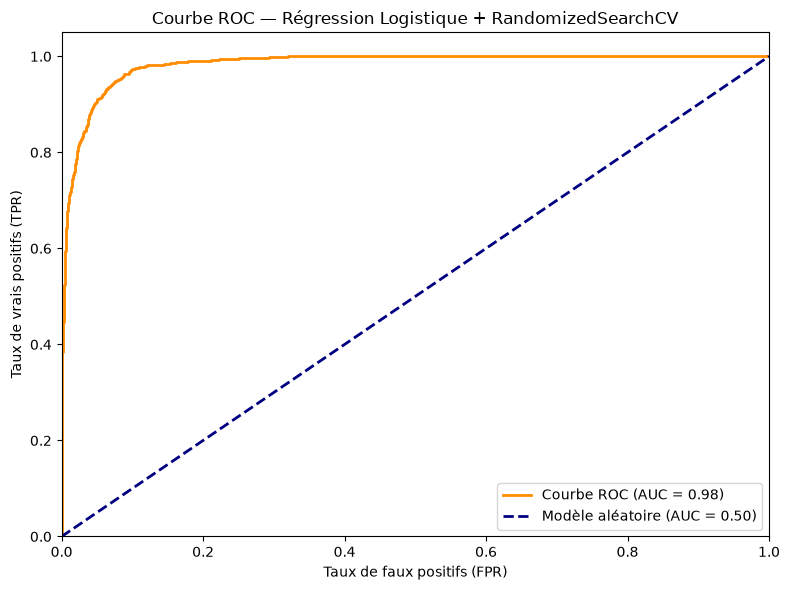

In [91]:
# ── Tracé de la courbe ROC ────────────────────────────────
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {area:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2,
         linestyle='--', label='Modèle aléatoire (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')

# modèle final sans rééchantillonnage
plt.title('Courbe ROC — Régression Logistique + RandomizedSearchCV')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 📊 Interprétation :
# AUC > 0.90 → excellent pouvoir discriminant
# AUC > 0.80 → bon modèle
# AUC = 0.50 → modèle sans pouvoir prédictif (aléatoire)

 AUC : 0.9833
  AUC > 0.90 → excellent pouvoir discriminant

### Evaluation du modèle : Rankordering, KS statistic, Gini coeff

In [92]:
# ── Rank Ordering (table des déciles) ────────────────────
# Trier les observations par probabilité de défaut décroissante
# Vérifier que les défauts se concentrent dans les premiers déciles

decile_df = pd.DataFrame({
    'y_test'      : y_test.values,
    'probability' : probabilities  
})

# Découpage en déciles selon la probabilité prédite
decile_df['decile'] = pd.qcut(
    decile_df['probability'], q=10, labels=False, duplicates='drop'
)
decile_df['decile'] = 9 - decile_df['decile']  # Décile 0 = probabilité la plus haute

# Agrégation par décile
rank_order = decile_df.groupby('decile').agg(
    total  = ('y_test', 'count'),
    events = ('y_test', 'sum'),
).reset_index()

rank_order['non_events']        = rank_order['total'] - rank_order['events']
rank_order['event_rate']        = (rank_order['events'] / rank_order['total']).round(4)
rank_order['cum_events']        = rank_order['events'].cumsum()
rank_order['cum_non_events']    = rank_order['non_events'].cumsum()
rank_order['cum_event_pct']     = (rank_order['cum_events'] / rank_order['events'].sum()).round(4)
rank_order['cum_non_event_pct'] = (rank_order['cum_non_events'] / rank_order['non_events'].sum()).round(4)

In [93]:
# Statistique KS par décile
rank_order['KS'] = (rank_order['cum_event_pct'] - rank_order['cum_non_event_pct']).abs().round(4)

print("Table des déciles — Rank Ordering :")
print(rank_order.to_string(index=False))

Table des déciles — Rank Ordering :
 decile  total  events  non_events  event_rate  cum_events  cum_non_events  cum_event_pct  cum_non_event_pct       KS
      0   1250     901         349    0.720800         901             349       0.838900           0.030600 0.808300
      1   1250     153        1097    0.122400        1054            1446       0.981400           0.126600 0.854800
      2   1249      15        1234    0.012000        1069            2680       0.995300           0.234600 0.760700
      3   1250       5        1245    0.004000        1074            3925       1.000000           0.343600 0.656400
      4   1249       0        1249    0.000000        1074            5174       1.000000           0.452900 0.547100
      5   1250       0        1250    0.000000        1074            6424       1.000000           0.562400 0.437600
      6   1250       0        1250    0.000000        1074            7674       1.000000           0.671800 0.328200
      7   1249      

#### Analyse de la table des déciles — Rank Ordering

#### 🔴 Déciles à fort risque (0 et 1) :
####    → Décile 0 : taux d'événements = 72.1% → le modèle concentre
####      83.9% de tous les défauts dans ce seul décile
####    → Décile 1 : taux d'événements = 12.2% → taux cumulé atteint 98.1%
####      dès le 2ème décile → quasi-totalité des défauts détectés
#### 🟡 Déciles intermédiaires (2 et 3) :
####    → Taux d'événements quasi nuls (1.2% et 0.4%)
####    → Taux cumulé atteint 100% dès le décile 3
#### 🟢 Déciles inférieurs (4 à 9) :
####    → Aucun défaut observé (event_rate = 0.000)
####    → 100% de non-défauts → le modèle n'envoie aucun défaut
####      dans la moitié inférieure du classement
####   KS maximum = 85.5% au décile 1
####    → Règle pratique : KS > 40% dans les 3 premiers déciles = bon modèle
####    → Ici KS = 85.5% au décile 1 → modèle excellent ✅

In [94]:
# ── KS Statistic ─────────────────────────────────────────
# KS = différence maximale entre la distribution cumulée
# des événements et des non-événements
# KS > 40% → bon modèle | KS > 60% → excellent modèle

ks_stat   = rank_order['KS'].max()
ks_decile = rank_order.loc[rank_order['KS'].idxmax(), 'decile']

print(f"KS Statistic  : {ks_stat:.4f} ({ks_stat*100:.2f}%)")
print(f"Décile optimal : {ks_decile}")

# 📊 Interprétation :
# < 0.20       → modèle faible
# 0.20 – 0.40  → modèle acceptable
# 0.40 – 0.60  → bon modèle
# > 0.60       → excellent modèle 

KS Statistic  : 0.8548 (85.48%)
Décile optimal : 1


Excellent modèle

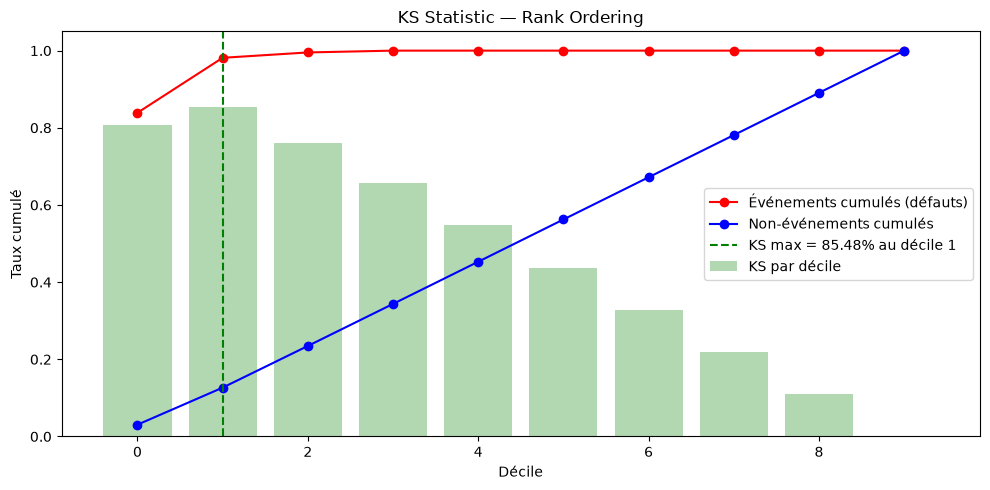

In [95]:
#  Visualisation KS
plt.figure(figsize=(10, 5))

plt.plot(rank_order['decile'], rank_order['cum_event_pct'],
         marker='o', label='Événements cumulés (défauts)', color='red')

plt.plot(rank_order['decile'], rank_order['cum_non_event_pct'],
         marker='o', label='Non-événements cumulés', color='blue')

plt.bar(rank_order['decile'], rank_order['KS'],
        alpha=0.3, color='green', label='KS par décile')

plt.axvline(x=ks_decile, color='green', linestyle='--',
            label=f'KS max = {ks_stat:.2%} au décile {ks_decile}')

plt.xlabel('Décile')
plt.ylabel('Taux cumulé')
plt.title('KS Statistic — Rank Ordering')
plt.legend()
plt.tight_layout()
plt.show()

Le modèle présente un excellent pouvoir discriminant avec un KS de 85.48%
atteint dès le décile 1, ce qui signifie que la quasi-totalité des défauts
est concentrée dans les 2 premiers déciles. La courbe des défauts (rouge)
atteint 100% très rapidement tandis que la courbe des non-défauts (bleue)
progresse linéairement, confirmant une très bonne séparation entre les deux
classes.
Le modèle est donc très efficace pour identifier les clients à risque.

In [96]:
# Gini Coefficient 
# Gini = 2 * AUC - 1
# Mesure la capacité du modèle à distinguer les classes
# Gini = 0 → modèle aléatoire | Gini = 1 → modèle parfait

gini_coefficient = 2 * area - 1

print(f"AUC              : {area:.4f}")
print(f"Gini Coefficient : {gini_coefficient:.4f}")

# 📊 Interprétation :
# < 0.20 → modèle faible
# 0.20–0.40 → modèle acceptable
# 0.40–0.60 → bon modèle
# > 0.60 → excellent modèle

AUC              : 0.9835
Gini Coefficient : 0.9671


Excellent modèle

## Finalisation du modèle et visualisation de l’importance des caractéristiques


In [97]:
final_model = best_model_logistic

### Importance des variables

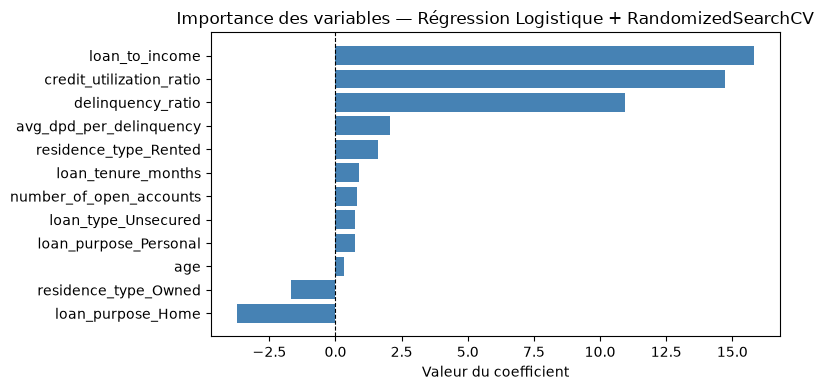

In [99]:
# Coefficient positif → augmente le risque de défaut
# Coefficient négatif → diminue le risque de défaut

feature_importance = final_model.coef_[0]

coef_df = pd.DataFrame(
    feature_importance,
    index=X_train_final.columns,
    columns=['Coefficients']
).sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Valeur du coefficient')

# modèle final retenu
plt.title("Importance des variables — Régression Logistique + RandomizedSearchCV")

plt.tight_layout()
plt.show()

### 🔴 Variables augmentant le risque de défaut (coefficients positifs) :
   → credit_utilization_ratio : variable la plus impactante
   
   → loan_to_income           : ratio endettement/revenu élevé = risque élevé
   
   → delinquency_ratio        : historique de retards = fort signal de défaut
### 🟢 Variables réduisant le risque de défaut (coefficients négatifs) :
   → loan_purpose_Home        : prêt immobilier = profil plus fiable
   
   → residence_type_Owned     : propriétaire = stabilité financière

## Sauvegarde du modèle

In [100]:
X_test_final.head(2)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,residence_type_Owned,residence_type_Rented,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency
19205,0.346154,0.754717,0.333333,0.989899,1,0,1,0,0,0.550351,0.000000,0.000000
15514,0.480769,0.226415,1.000000,0.323232,1,0,0,0,0,0.220141,0.000000,0.000000


In [101]:
X_test_final.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'],
      dtype='str')

In [102]:
cols_to_scale

['age',
 'number_of_dependants',
 'years_at_current_address',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [104]:
from joblib import dump

model_data = {
    'model'        : final_model,
    'features'     : X_train_final.columns,
    'scaler'       : scaler,
    'cols_to_scale': cols_to_scale
}

dump(model_data, 'model_data.joblib')
print("Modèle sauvegardé dans 'model_data.joblib'")

Modèle sauvegardé dans 'model_data.joblib'


In [105]:
print("Coefficients  :", final_model.coef_)
print("Intercept     :", final_model.intercept_)

Coefficients  : [[ 0.32337211  0.90590142  0.79850893 14.72726309 -1.66494886  1.60391384
  -3.73783471  0.75221479  0.75221479 15.82418595 10.95975342  2.07235893]]
Intercept     : [-20.69757569]


In [106]:
# ── Aperçu des coefficients du modèle 
coef_df = pd.DataFrame(
    final_model.coef_[0],
    index=X_train_final.columns,
    columns=['Coefficients']
).sort_values('Coefficients', ascending=False)

print("Intercept :", round(final_model.intercept_[0], 4))
print()
print(coef_df)

Intercept : -20.6976

                          Coefficients
loan_to_income               15.824186
credit_utilization_ratio     14.727263
delinquency_ratio            10.959753
avg_dpd_per_delinquency       2.072359
residence_type_Rented         1.603914
loan_tenure_months            0.905901
number_of_open_accounts       0.798509
loan_purpose_Personal         0.752215
loan_type_Unsecured           0.752215
age                           0.323372
residence_type_Owned         -1.664949
loan_purpose_Home            -3.737835
